In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.tree import plot_tree
from scipy.interpolate import interp1d

%pip install mlxtend
from mlxtend.evaluate import bias_variance_decomp
import sklearn.metrics as metrics

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

from collections import defaultdict

Note: you may need to restart the kernel to use updated packages.


<h2>Section 1: Data Preparation & Setup</h2>

Combined Cycle Power Plant Data Set<br>

Data Set Information:<br>

This UCI dataset contains 9568 data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP) of the plant.<br>



The power plant being at full load means that there shouldn't be any confounding due to variations in the independent variables.


Attribute Information:<br>

Features consist of hourly average ambient variables:

| Feature | Range |
| -------- | -------- |
| Temperature (T)   | 1.81°C - 37.11°C  |
| Ambient Pressure (AP)   | 992.89 - 1033.30 milibar  |
| Relative Humidity (RH)   | 25.56% - 100.16%  |
| Exhaust Vacuum (V)   | 25.36 - 81.56 cm Hg  |
| Net hourly electrical energy output (EP)   | 420.26 - 495.76 MW  |
|Table 1.

In [2]:
ppep_df = pd.read_csv('data/Power Plant Data.csv')

ppep_df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


The dataset is sorted by net hourly electrical output (PE) to perform a quick visual analysis of correlation with other variables.

In [3]:
ppep_df_sorted = ppep_df.sort_values('AT')
ppep_df_sorted = ppep_df.sort_values('AP')
ppep_df_sorted = ppep_df.sort_values('V')
ppep_df_sorted = ppep_df.sort_values('RH')
ppep_df_sorted = ppep_df.sort_values('PE').reset_index(drop=True)

print(f"Table 2\n{ppep_df_sorted}")

Table 2
         AT      V       AP     RH      PE
0     24.27  63.87  1018.88  53.96  420.26
1     23.00  66.05  1020.61  80.29  421.57
2     32.56  68.14  1004.02  35.04  425.11
3     31.74  72.58  1007.26  59.58  425.12
4     29.67  71.98  1005.16  67.75  425.14
...     ...    ...      ...    ...     ...
9563   6.17  40.07  1013.70  58.99  495.21
9564   5.25  40.07  1019.48  67.70  495.23
9565   5.41  40.07  1019.16  64.77  495.24
9566   5.15  40.07  1012.27  63.31  495.35
9567   5.48  40.07  1019.63  65.62  495.76

[9568 rows x 5 columns]


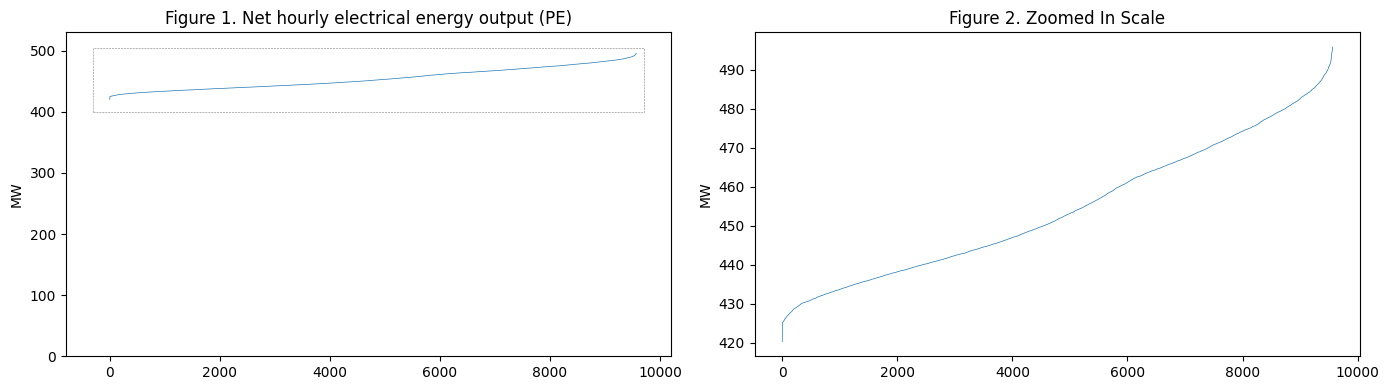

In [4]:
fig = plt.figure(figsize=(14,4))

lfig = fig.add_subplot(121)

plt.title('Figure 1. Net hourly electrical energy output (PE)')

plt.ylabel('MW')

plt.ylim([0,530])

lfig.plot(ppep_df_sorted.index, ppep_df_sorted['PE'], linewidth=0.5)

rect = Rectangle((-300, 400), 10000, 105, 
                 linewidth=.4,
                 edgecolor='gray',
                 linestyle='dashed',
                 facecolor='none')

lfig.add_patch(rect)

rfig = fig.add_subplot(122)

plt.title('Figure 2. Zoomed In Scale')

plt.ylabel('MW')

rfig.plot(ppep_df_sorted['PE'], linewidth=0.5)

plt.tight_layout()

plt.show()

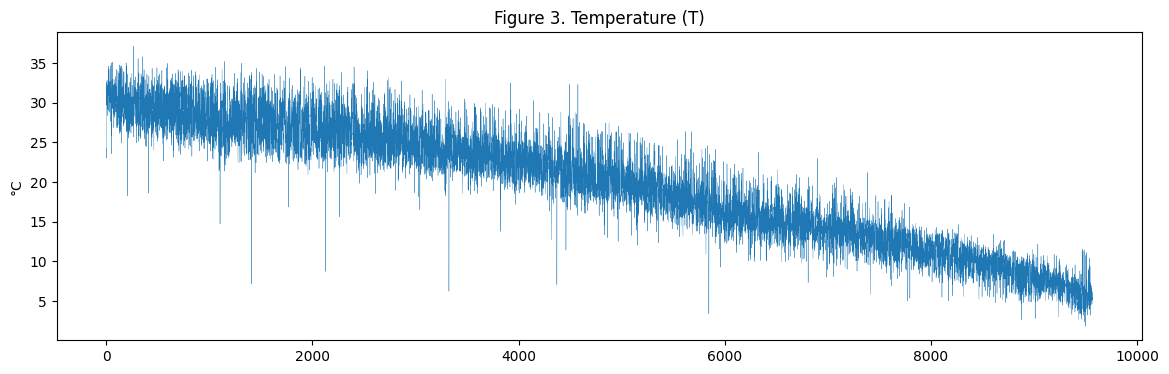

In [5]:
fig = plt.figure(figsize=(14,4))

plt.title('Figure 3. Temperature (T)')

plt.ylabel('°C')

plt.plot(ppep_df_sorted['AT'], linewidth=0.25)

plt.show()

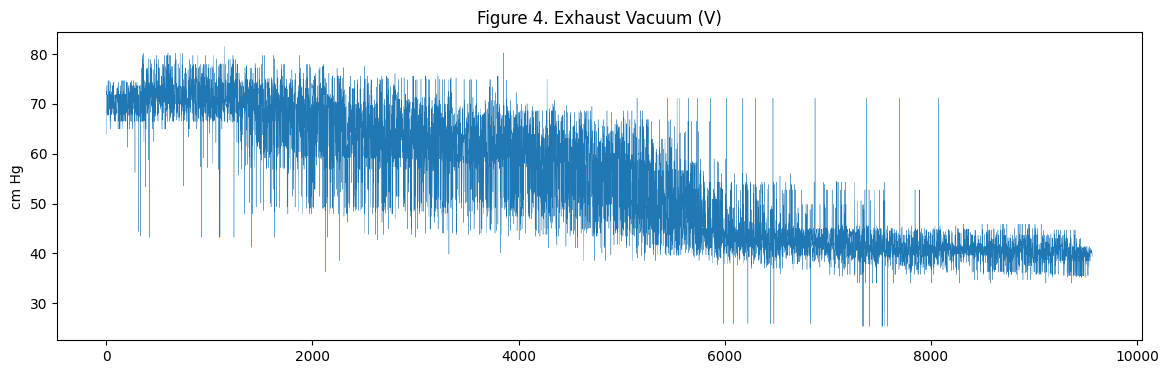

In [6]:
fig = plt.figure(figsize=(14,4))

plt.title('Figure 4. Exhaust Vacuum (V)')

plt.ylabel('cm Hg')

plt.plot(ppep_df_sorted['V'], linewidth=0.25)

plt.show()

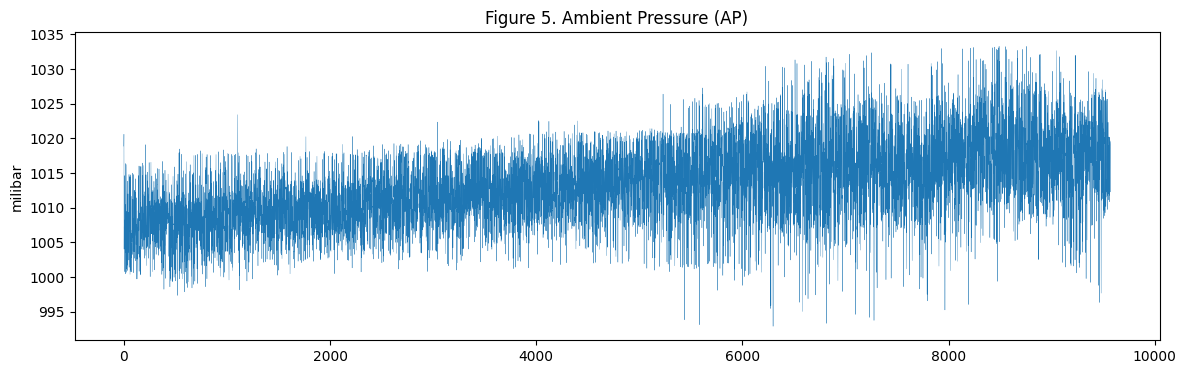

In [7]:
fig = plt.figure(figsize=(14,4))

plt.title('Figure 5. Ambient Pressure (AP)')

plt.ylabel('milibar')

plt.plot(ppep_df_sorted['AP'], linewidth=0.25)

plt.show()

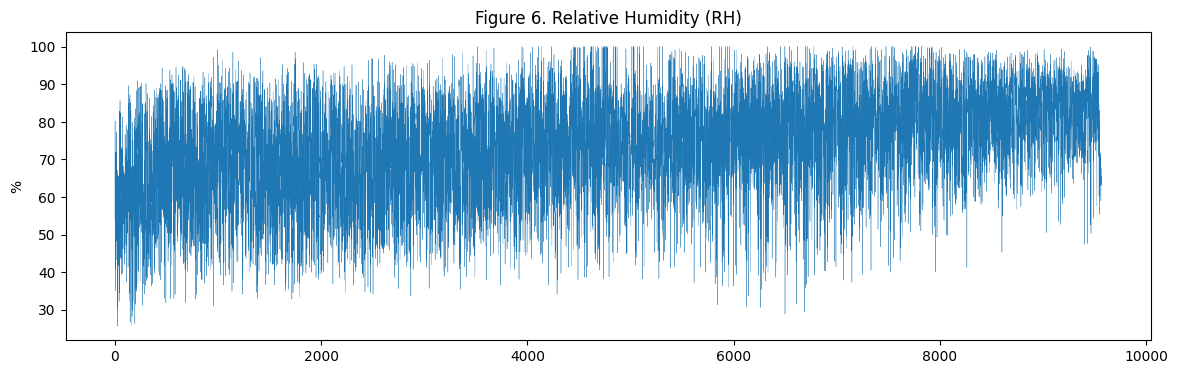

In [8]:
fig = plt.figure(figsize=(14,4))

plt.title('Figure 6. Relative Humidity (RH)')

plt.ylabel('%')

plt.plot(ppep_df_sorted['RH'], linewidth=0.25)

plt.show()

A quick visual analysis of the dataset shows an inversely proportional relationship between {exhaust vacuum, temperature} and electrical output. A proportional relationship is shown between {ambient pressure, relative humidity} and electrical output. This should mean that it is possible to accurately predict electrical output based on these variables.

In [9]:
ppep_df_sorted_subset = ppep_df_sorted.dropna(axis=0).reset_index(drop = True)

print(f"Table 3\n{ppep_df_sorted_subset}")

Table 3
         AT      V       AP     RH      PE
0     24.27  63.87  1018.88  53.96  420.26
1     23.00  66.05  1020.61  80.29  421.57
2     32.56  68.14  1004.02  35.04  425.11
3     31.74  72.58  1007.26  59.58  425.12
4     29.67  71.98  1005.16  67.75  425.14
...     ...    ...      ...    ...     ...
9563   6.17  40.07  1013.70  58.99  495.21
9564   5.25  40.07  1019.48  67.70  495.23
9565   5.41  40.07  1019.16  64.77  495.24
9566   5.15  40.07  1012.27  63.31  495.35
9567   5.48  40.07  1019.63  65.62  495.76

[9568 rows x 5 columns]


In [10]:
ppep_df_sorted_subset = pd.get_dummies(ppep_df_sorted_subset, drop_first = True)

print(f"Table 4\n{ppep_df_sorted_subset}")

Table 4
         AT      V       AP     RH      PE
0     24.27  63.87  1018.88  53.96  420.26
1     23.00  66.05  1020.61  80.29  421.57
2     32.56  68.14  1004.02  35.04  425.11
3     31.74  72.58  1007.26  59.58  425.12
4     29.67  71.98  1005.16  67.75  425.14
...     ...    ...      ...    ...     ...
9563   6.17  40.07  1013.70  58.99  495.21
9564   5.25  40.07  1019.48  67.70  495.23
9565   5.41  40.07  1019.16  64.77  495.24
9566   5.15  40.07  1012.27  63.31  495.35
9567   5.48  40.07  1019.63  65.62  495.76

[9568 rows x 5 columns]


In [11]:
y = ppep_df_sorted_subset["PE"]

X = ppep_df_sorted_subset.copy()
X = X.drop("PE", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

<h2>Section 2: Model Building & Performance Comparison</h2>

<h3>2.1 Single Decision Tree</h3>

Decision Tree Regressor Mean Squared Error: 20.007596655518398


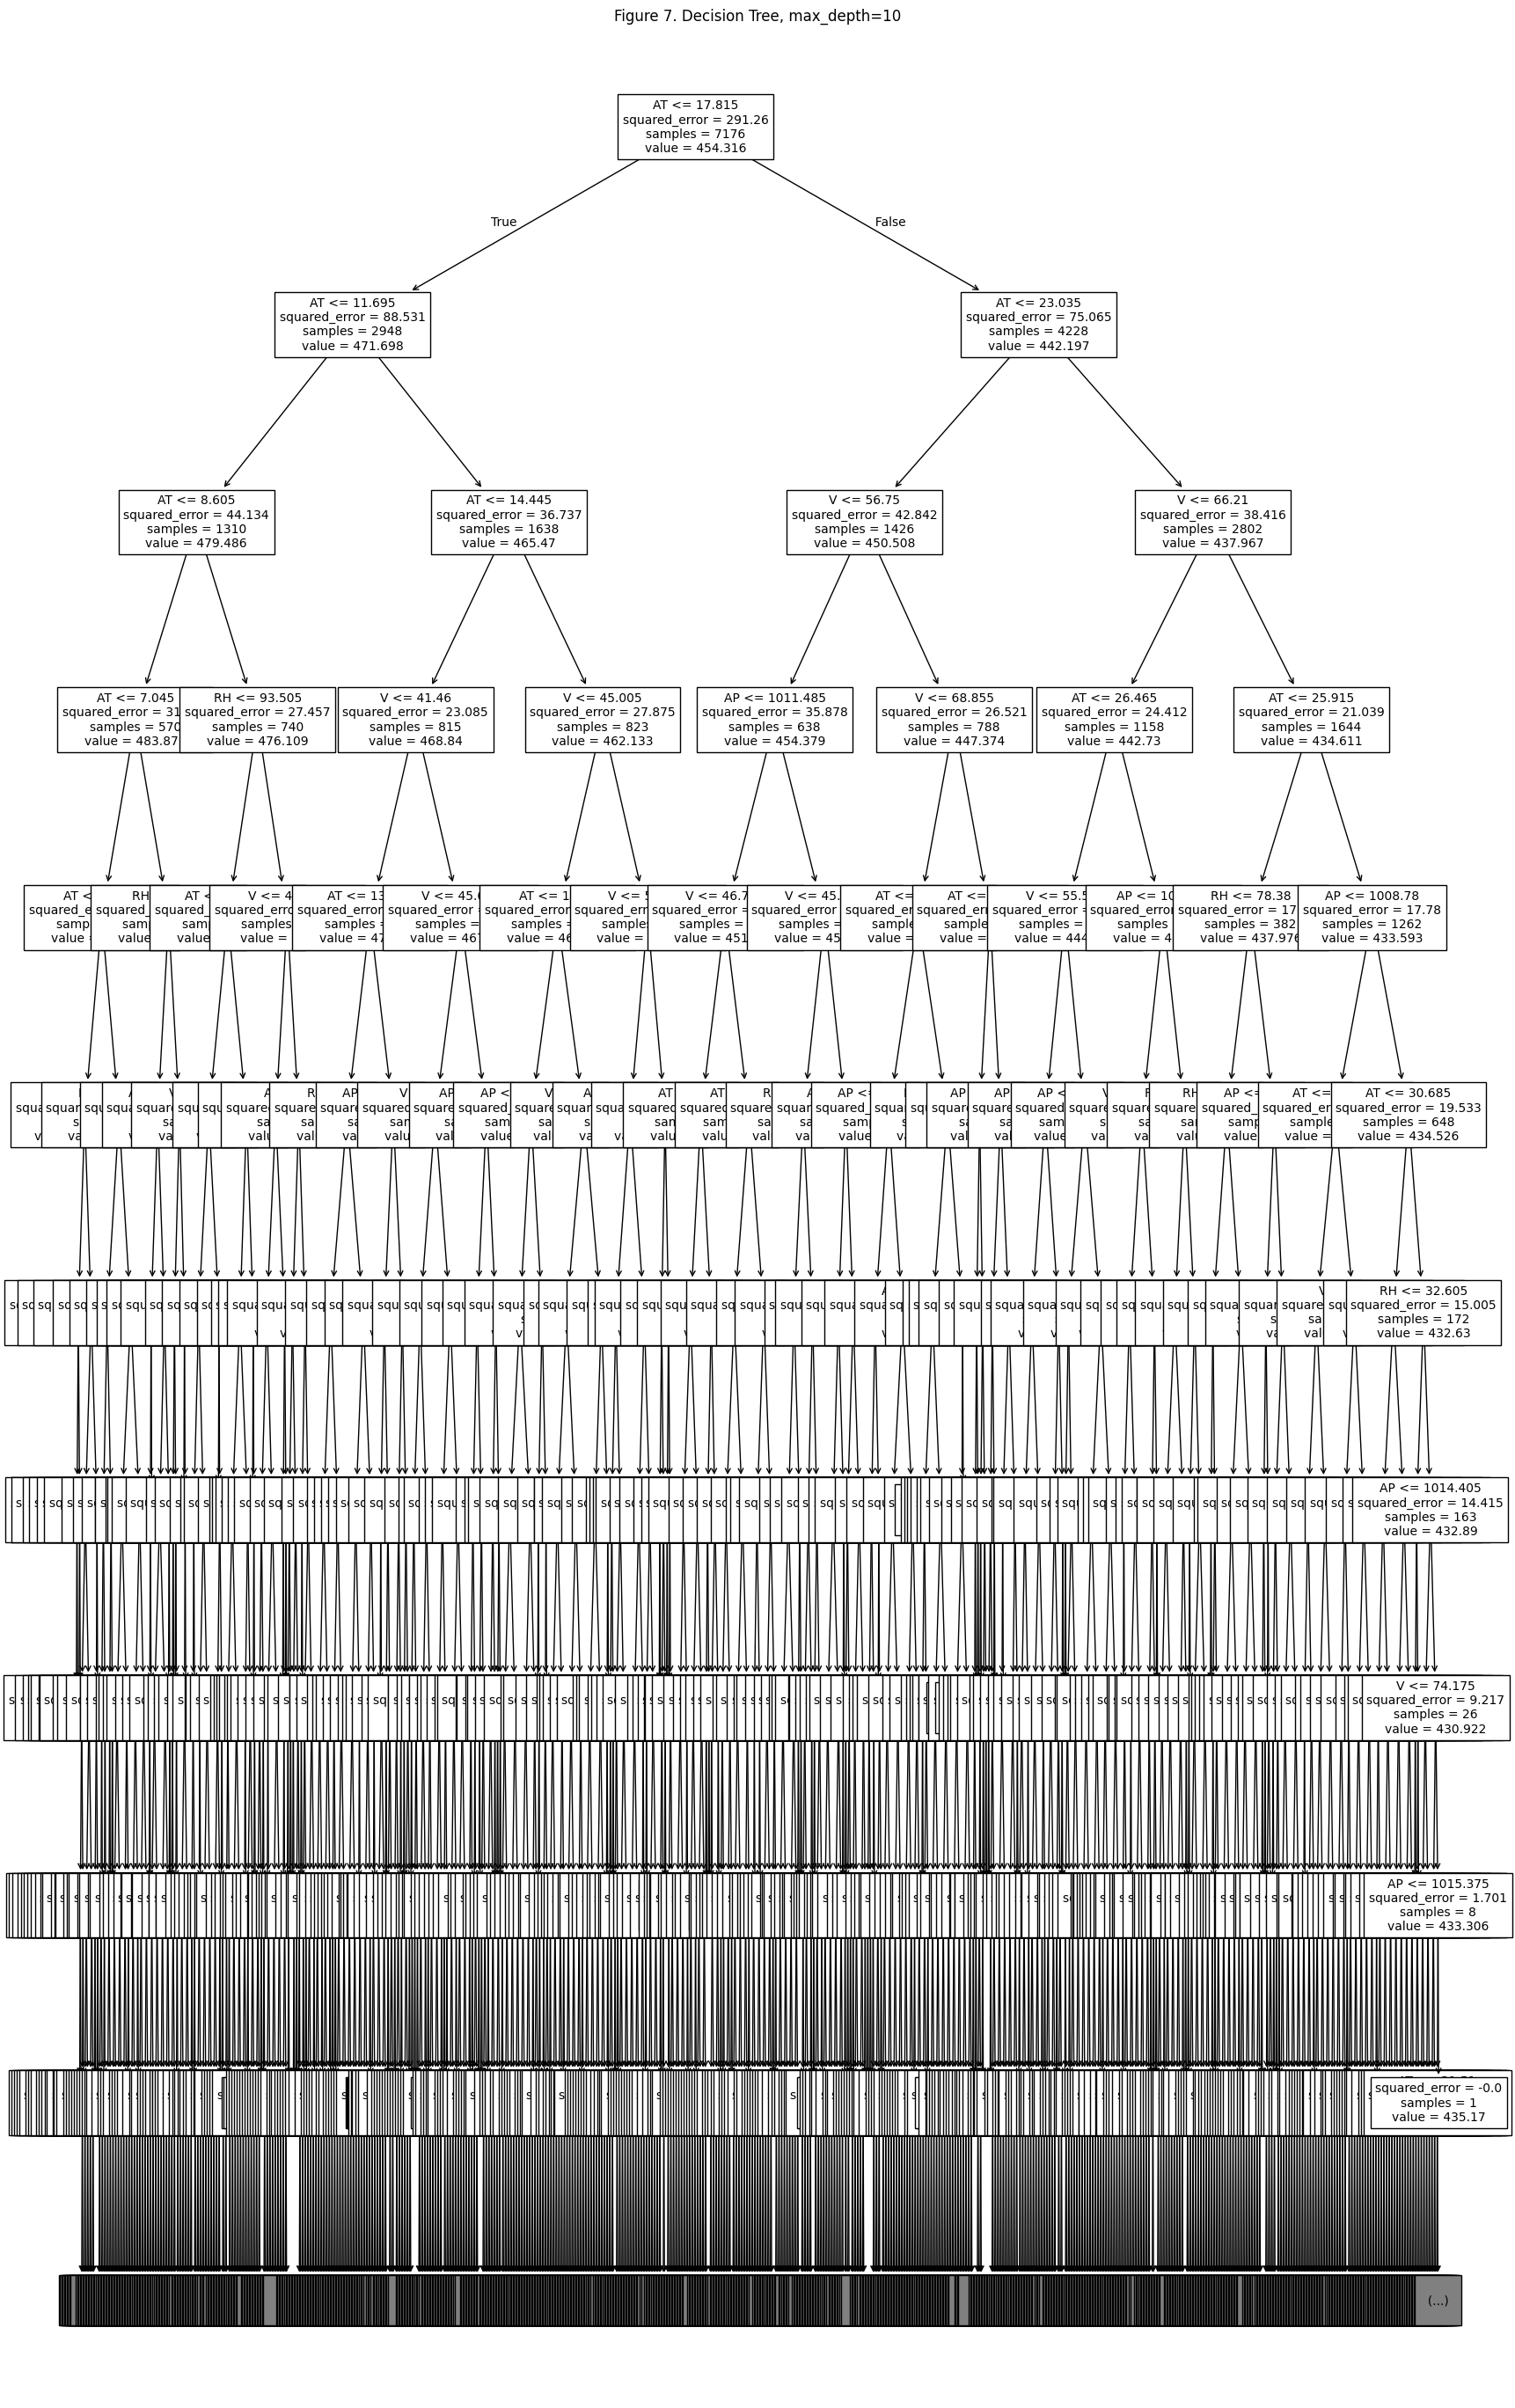

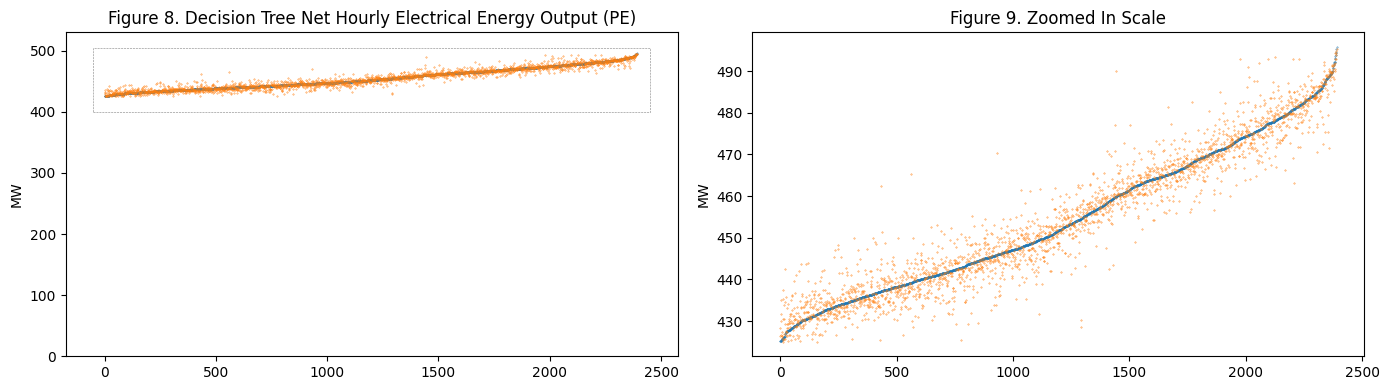

In [12]:
dtregressor = DecisionTreeRegressor(random_state=42)

dtregressor.fit(X_train, y_train)

dtregressor_y_pred = dtregressor.predict(X_test)

dtregressor_mse = metrics.mean_squared_error(y_test, dtregressor_y_pred)
print(f"Decision Tree Regressor Mean Squared Error: {dtregressor_mse}")

plt.figure(figsize=(20,35))
plot_tree(dtregressor, max_depth=10, fontsize=10, feature_names=X.columns)
plt.title(f"Figure 7. Decision Tree, max_depth=10")
plt.show()

dtregressor_y_df = pd.DataFrame()
dtregressor_y_df['y_test'] = y_test
dtregressor_y_df['y_pred'] = dtregressor_y_pred
dtregressor_y_df = dtregressor_y_df.sort_values('y_test').reset_index(drop=True)

fig = plt.figure(figsize=(14,4))

lfig = fig.add_subplot(121)

plt.title('Figure 8. Decision Tree Net Hourly Electrical Energy Output (PE)')

plt.ylabel('MW')

plt.ylim([0,530])

lfig.scatter(dtregressor_y_df.index, dtregressor_y_df['y_test'], s=.1)
lfig.scatter(dtregressor_y_df.index, dtregressor_y_df['y_pred'], s=.1)

rect = Rectangle((-50, 400), 2500, 105, 
                 linewidth=.4,
                 edgecolor='gray',
                 linestyle='dashed',
                 facecolor='none')

lfig.add_patch(rect)

rfig = fig.add_subplot(122)

plt.title('Figure 9. Zoomed In Scale')

plt.ylabel('MW')

rfig.scatter(dtregressor_y_df.index, dtregressor_y_df['y_test'], s=.1)
rfig.scatter(dtregressor_y_df.index, dtregressor_y_df['y_pred'], s=.1)

plt.tight_layout()

plt.show()

The decision tree used above is a regression tree on continuous variables to predict the expected electrical output (PE). In simple terms, a decision tree recursively divides a full dataset into smaller segments. A boundary metric is used to split a parent leaf into children leafs. Each variable is used to calculate the root mean squared error (RMSE) and the lowest RMSE is used as the split criteria. This calculation is continued until the maximum tree depth is reached. The result is a prediction of PE based on following the leafs from start to end based on variable values.

<h3>2.2 Random Forest</h3>

Random Forest Regressor Mean Squared Error: 11.001372567232746


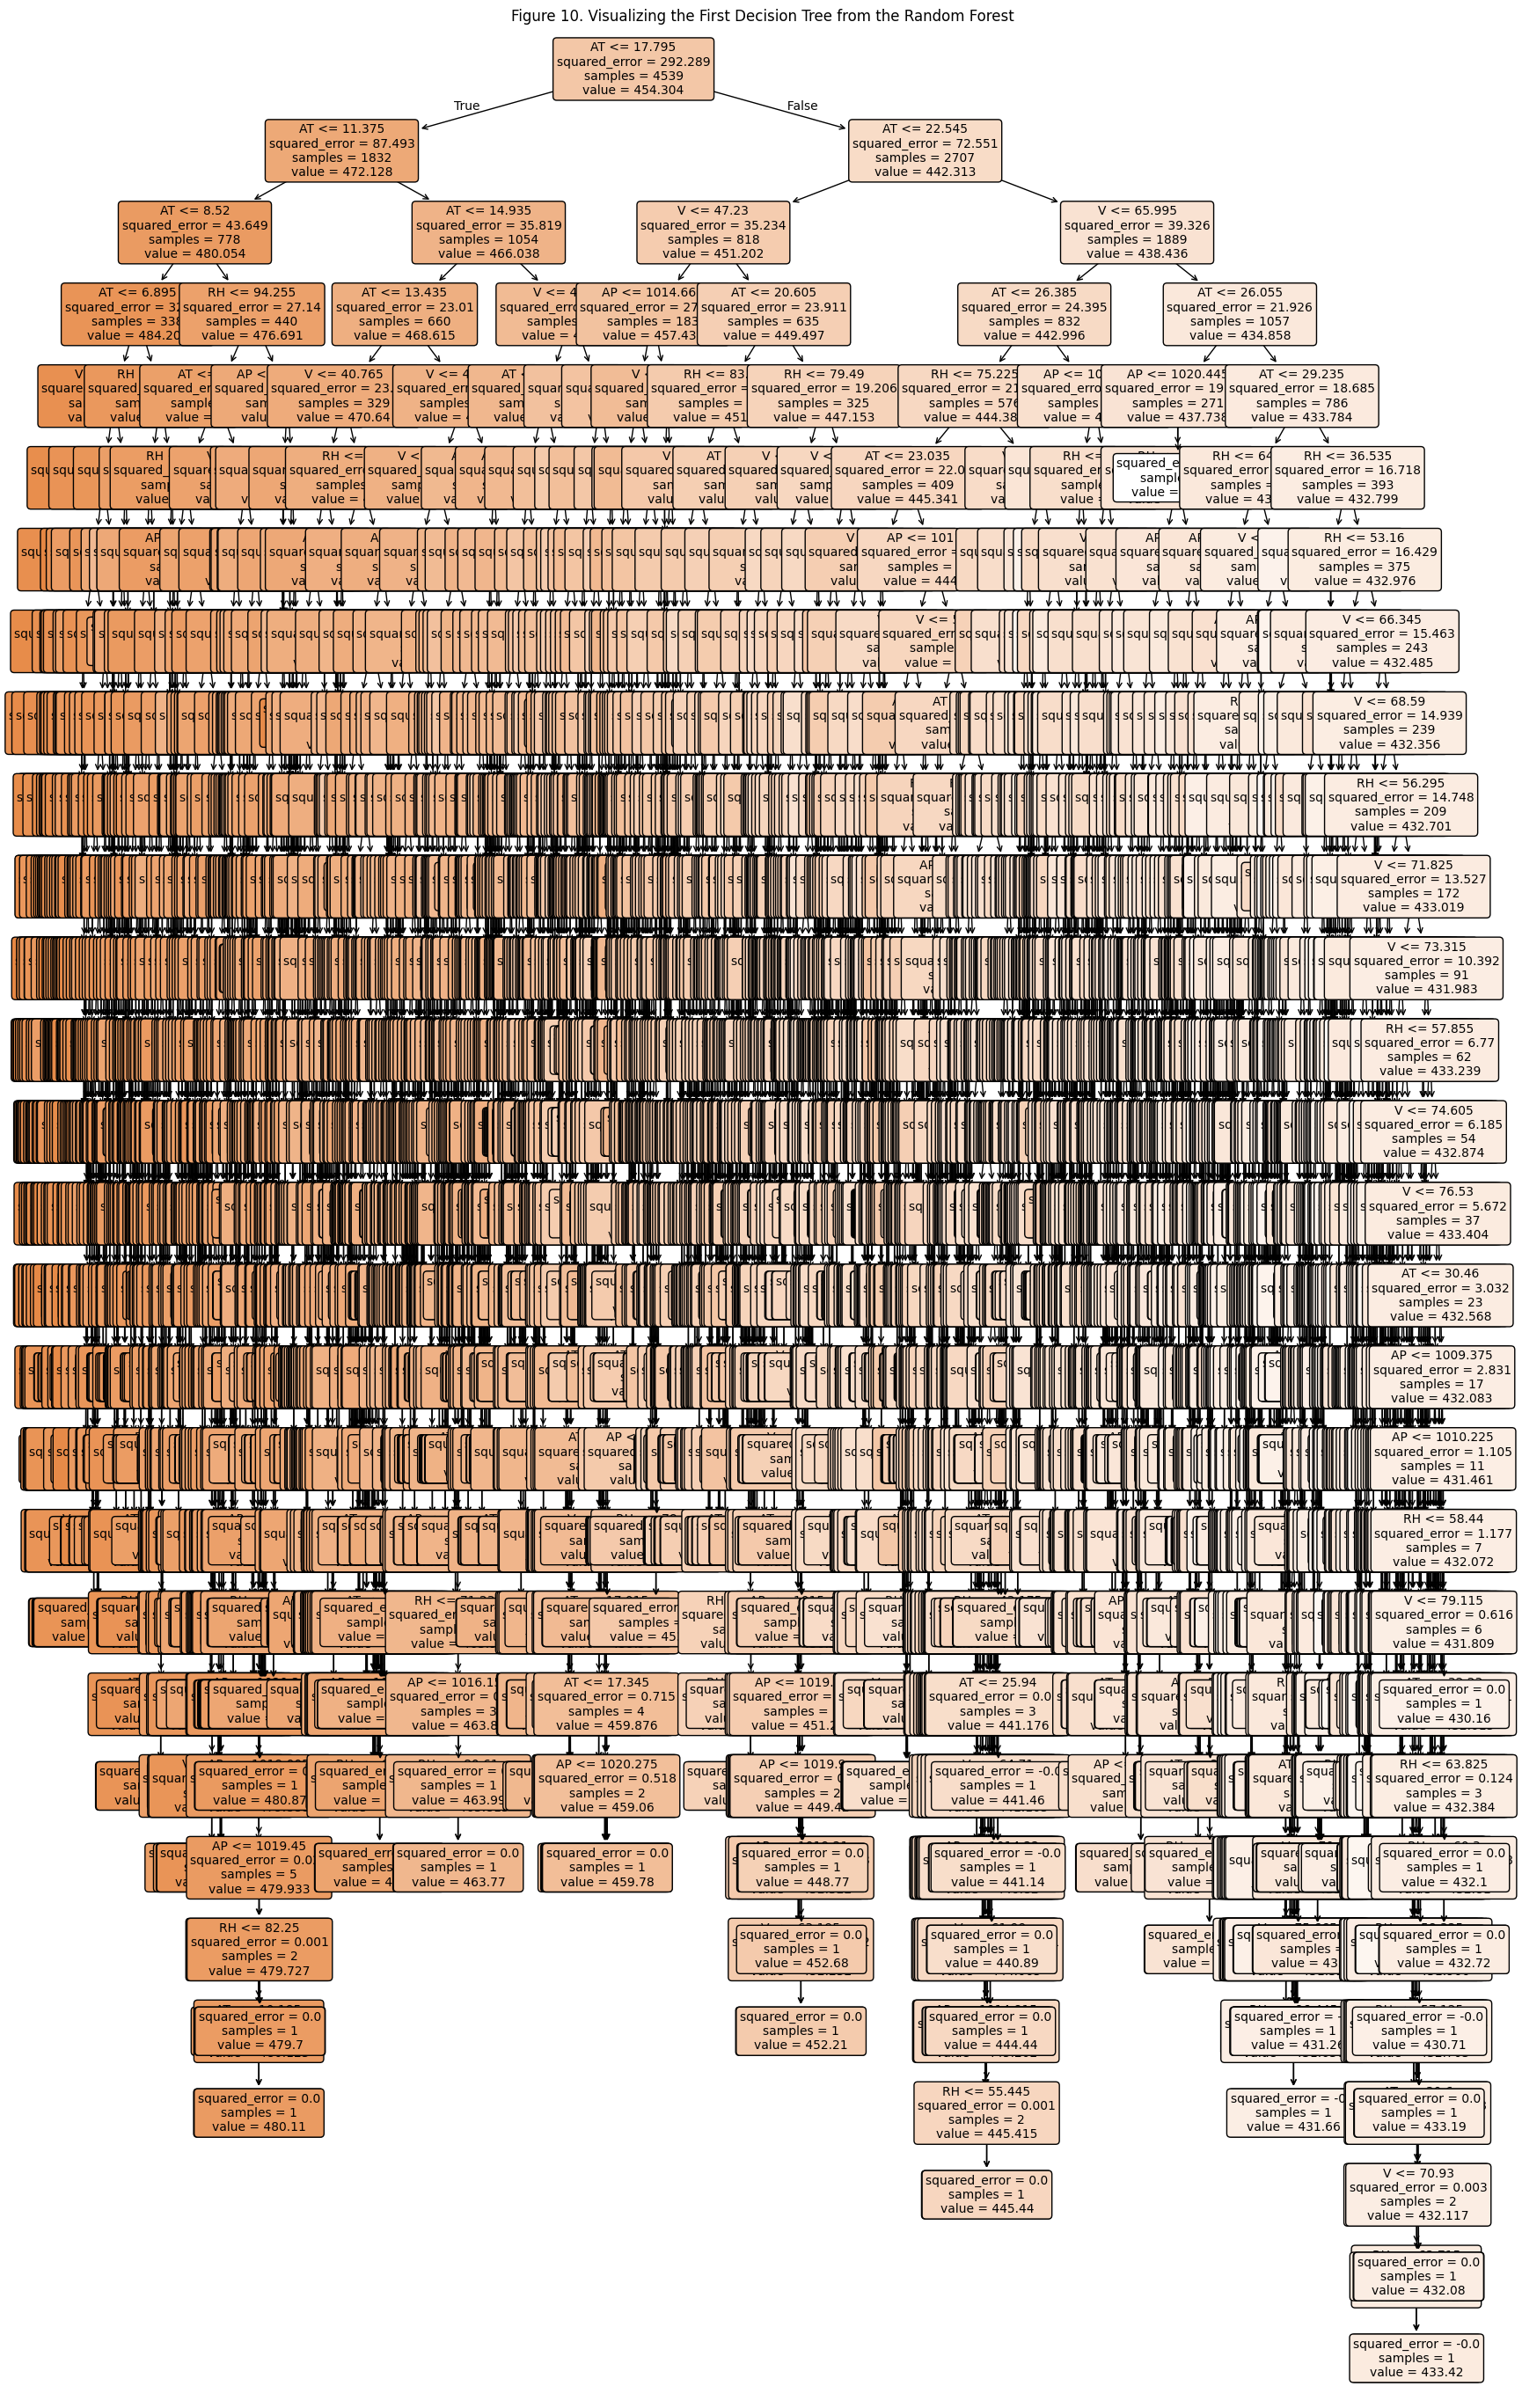

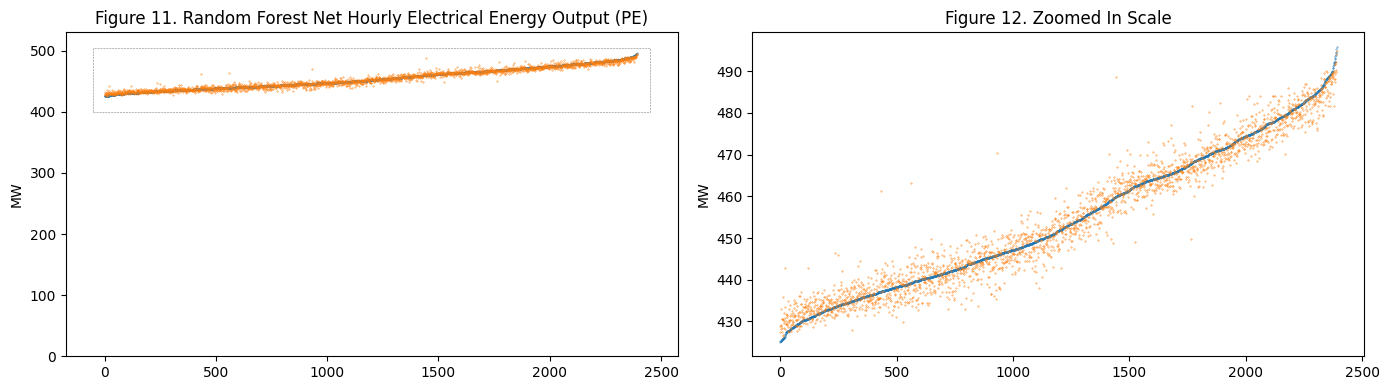

In [13]:
rf_regressor = RandomForestRegressor(n_estimators=1000, random_state=42)

rf_regressor.fit(X_train, y_train)

rfregressor_y_pred = rf_regressor.predict(X_test)

rfregressor_mse = metrics.mean_squared_error(y_test, rfregressor_y_pred)

print(f"Random Forest Regressor Mean Squared Error: {rfregressor_mse}")

first_tree = rf_regressor.estimators_[0]

plt.figure(figsize=(20, 35))

plot_tree(first_tree,
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Figure 10. Visualizing the First Decision Tree from the Random Forest")

plt.show()

rfregressor_y_df = pd.DataFrame()
rfregressor_y_df['y_test'] = y_test
rfregressor_y_df['y_pred'] = rfregressor_y_pred
rfregressor_y_df = rfregressor_y_df.sort_values('y_test').reset_index(drop=True)

fig = plt.figure(figsize=(14,4))

lfig = fig.add_subplot(121)

plt.title('Figure 11. Random Forest Net Hourly Electrical Energy Output (PE)')

plt.ylabel('MW')

plt.ylim([0,530])

lfig.scatter(rfregressor_y_df.index, rfregressor_y_df['y_test'], s=.1)
lfig.scatter(rfregressor_y_df.index, rfregressor_y_df['y_pred'], s=.1)

rect = Rectangle((-50, 400), 2500, 105, 
                 linewidth=.4,
                 edgecolor='gray',
                 linestyle='dashed',
                 facecolor='none')

lfig.add_patch(rect)

rfig = fig.add_subplot(122)

plt.title('Figure 12. Zoomed In Scale')

plt.ylabel('MW')

rfig.scatter(rfregressor_y_df.index, rfregressor_y_df['y_test'], s=.1)
rfig.scatter(rfregressor_y_df.index, rfregressor_y_df['y_pred'], s=.1)

plt.tight_layout()

plt.show()

A random forest is a collection of individual decision trees. The basis of developing a random forest model is bootstrapping multiple datasets and creating individual trees from each. The process of bootstrapping is creating multiple datasets from the initial dataset. Some amount of samples are selected - sampling with replacement - at random from the entire dataset, and that sample dataset is used to build a decision tree. These individual trees are then averaged to create a more robust predictive model.

<h3>2.3 Gradient Boosting</h3>

Gradient Boost Regressor Mean Squared Error: 15.076458354814003


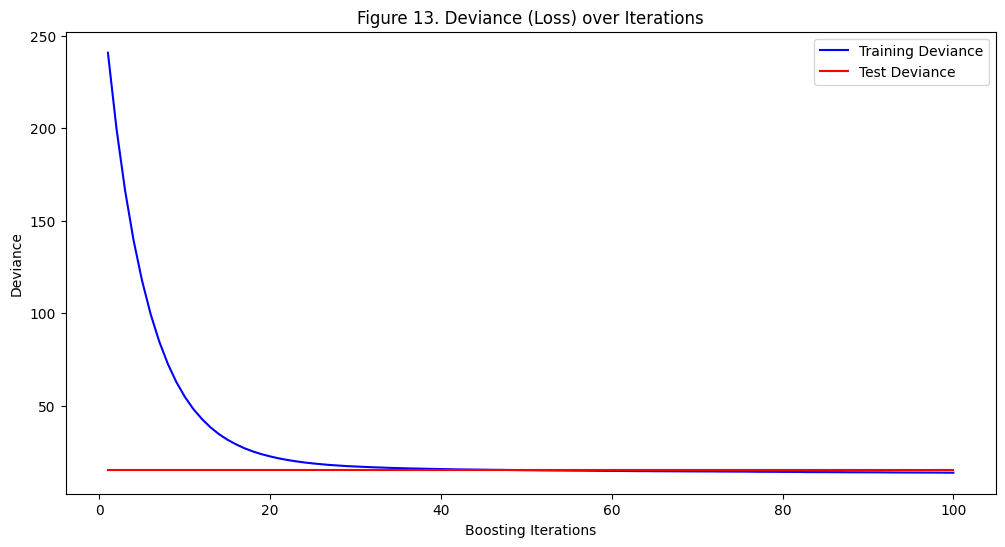

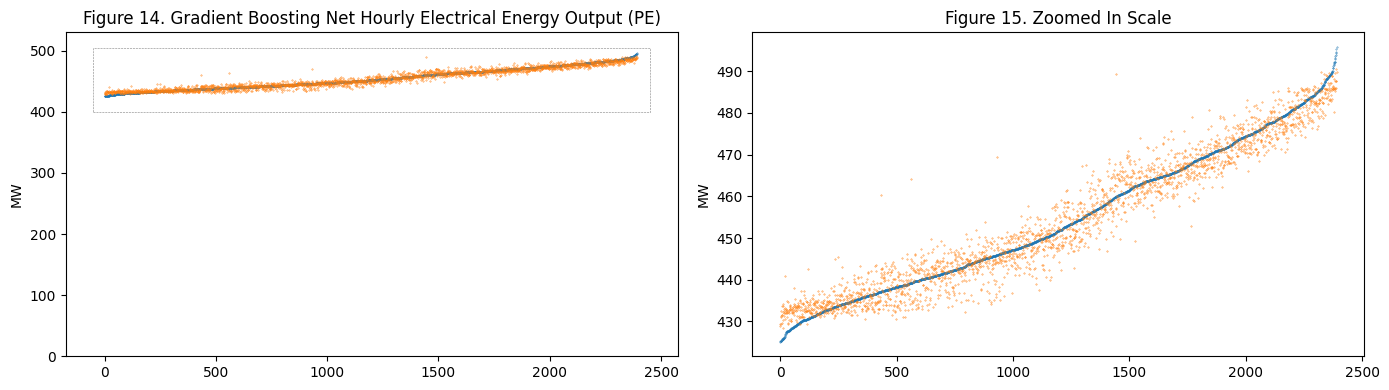

In [14]:
gb_regressor = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    loss='squared_error'
)

gb_regressor.fit(X_train, y_train)

gbregressor_y_pred = gb_regressor.predict(X_test)

gbregressor_mse = metrics.mean_squared_error(y_test, gbregressor_y_pred)
print(f"Gradient Boost Regressor Mean Squared Error: {gbregressor_mse}")

test_score = np.zeros((gb_regressor.n_estimators,), dtype=float)
for i, pred in enumerate(gb_regressor.staged_predict(X_test)):
    test_score[i] = metrics.mean_squared_error(y_test, gbregressor_y_pred)

plt.figure(figsize=(12, 6))
plt.subplot(1, 1, 1)
plt.title('Figure 13. Deviance (Loss) over Iterations')
plt.plot(np.arange(gb_regressor.n_estimators) + 1, gb_regressor.train_score_, 'b-',
         label='Training Deviance')
plt.plot(np.arange(gb_regressor.n_estimators) + 1, test_score, 'r-',
         label='Test Deviance')
plt.legend(loc='upper right')
plt.xlabel('Boosting Iterations')
plt.ylabel('Deviance')
plt.show()


gbregressor_y_df = pd.DataFrame()
gbregressor_y_df['y_test'] = y_test
gbregressor_y_df['y_pred'] = gbregressor_y_pred
gbregressor_y_df = gbregressor_y_df.sort_values('y_test').reset_index(drop=True)

fig = plt.figure(figsize=(14,4))

lfig = fig.add_subplot(121)

plt.title('Figure 14. Gradient Boosting Net Hourly Electrical Energy Output (PE)')

plt.ylabel('MW')

plt.ylim([0,530])

lfig.scatter(gbregressor_y_df.index, gbregressor_y_df['y_test'], s=.1)
lfig.scatter(gbregressor_y_df.index, gbregressor_y_df['y_pred'], s=.1)

rect = Rectangle((-50, 400), 2500, 105, 
                 linewidth=.4,
                 edgecolor='gray',
                 linestyle='dashed',
                 facecolor='none')

lfig.add_patch(rect)

rfig = fig.add_subplot(122)

plt.title('Figure 15. Zoomed In Scale')

plt.ylabel('MW')

rfig.scatter(gbregressor_y_df.index, gbregressor_y_df['y_test'], s=.1)
rfig.scatter(gbregressor_y_df.index, gbregressor_y_df['y_pred'], s=.1)

plt.tight_layout()

plt.show()


Gradient Boost is an ensemble learning method, similar to Random Forests, except for being sequential, rather than parallel. From the lecture notes:<br>

<blockquote>The key insight of gradient
boosting is viewing boosting as
gradient descent in function
space.<br>

This approach enables
optimization across diverse
predictive tasks.</blockquote>

Gradient descent in the function space is defined as optimizing the whole function rather than just weights and biases. New models - weak learners - are added to the function space that point in the negative direction of the loss function. Rather than being multiplicative, like Random Forests, Gradient Boosting relies on summation. From the lecture notes:

<blockquote>The final model is a
weighted sum of all
weak learners.</blockquote>


<h3>2.4 Performance Comparison Table</h3>

In [15]:
ppep_df_sorted_subset = ppep_df_sorted.dropna(axis=0).reset_index(drop = True)

ppep_df_sorted_subset = ppep_df_sorted_subset.astype(int)

ppep_df_sorted_subset = pd.get_dummies(ppep_df_sorted_subset, drop_first = True)

y_classifier = ppep_df_sorted_subset["PE"]

X_classifier = ppep_df_sorted_subset.copy()

X_classifier = X_classifier.drop("PE", axis = 1)

X_train_classifier, X_test_classifier, y_train_classifier, y_test_classifier = train_test_split(X_classifier, 
                                                                                                y_classifier, 
                                                                                                test_size=0.25, 
                                                                                                random_state=0)

In [16]:
dtclassifier = DecisionTreeClassifier(random_state=42)
rfclassifier = RandomForestClassifier(random_state=42)
gbclassifier = GradientBoostingClassifier(random_state=42)

dtclassifier.fit(X_train_classifier, y_train_classifier)
rfclassifier.fit(X_train_classifier, y_train_classifier)
gbclassifier.fit(X_train_classifier, y_train_classifier)

dtclassifier_y_pred = dtclassifier.predict(X_test)
rfclassifier_y_pred = rfclassifier.predict(X_test)
gbclassifier_y_pred = gbclassifier.predict(X_test)

dtregressor_mse = metrics.mean_squared_error(y_test, dtregressor_y_pred)
rfregressor_mse = metrics.mean_squared_error(y_test, rfregressor_y_pred)
gbregressor_mse = metrics.mean_squared_error(y_test, gbregressor_y_pred)

dtclassifier_accuracy = metrics.accuracy_score(y_test_classifier, dtclassifier_y_pred)
rfclassifier_accuracy = metrics.accuracy_score(y_test_classifier, rfclassifier_y_pred)
gbclassifier_accuracy = metrics.accuracy_score(y_test_classifier, gbclassifier_y_pred)

print(f"Decision Tree Regressor Mean Squared Error: {dtregressor_mse}")
print(f"Decision Tree Accuracy: {dtclassifier_accuracy}")
print(f"Random Forest Regressor Mean Squared Error: {rfregressor_mse}")
print(f"Random Forest Classifier Accuracy: {rfclassifier_accuracy}")
print(f"Gradient Boost Regressor Mean Squared Error: {gbregressor_mse}")
print(f"Gradient Boost Classifier Accuracy: {gbclassifier_accuracy}")

Decision Tree Regressor Mean Squared Error: 20.007596655518398
Decision Tree Accuracy: 0.10911371237458194
Random Forest Regressor Mean Squared Error: 11.001372567232746
Random Forest Classifier Accuracy: 0.11580267558528429
Gradient Boost Regressor Mean Squared Error: 15.076458354814003
Gradient Boost Classifier Accuracy: 0.11036789297658862


In [17]:
model_df = pd.DataFrame([[dtregressor_mse, dtclassifier_accuracy],
                         [rfregressor_mse, rfclassifier_accuracy],
                         [gbregressor_mse, gbclassifier_accuracy]],
                        index=['Decision Tree', 'Random Forest', 'Gradient Boost'],
                        columns=[['Regressor: Mean Squared Error', 'Classifier: Accuracy']]).T

Table 5
                               Decision Tree  Random Forest  Gradient Boost
Regressor: Mean Squared Error      20.007597      11.001373       15.076458
Classifier: Accuracy                0.109114       0.115803        0.110368


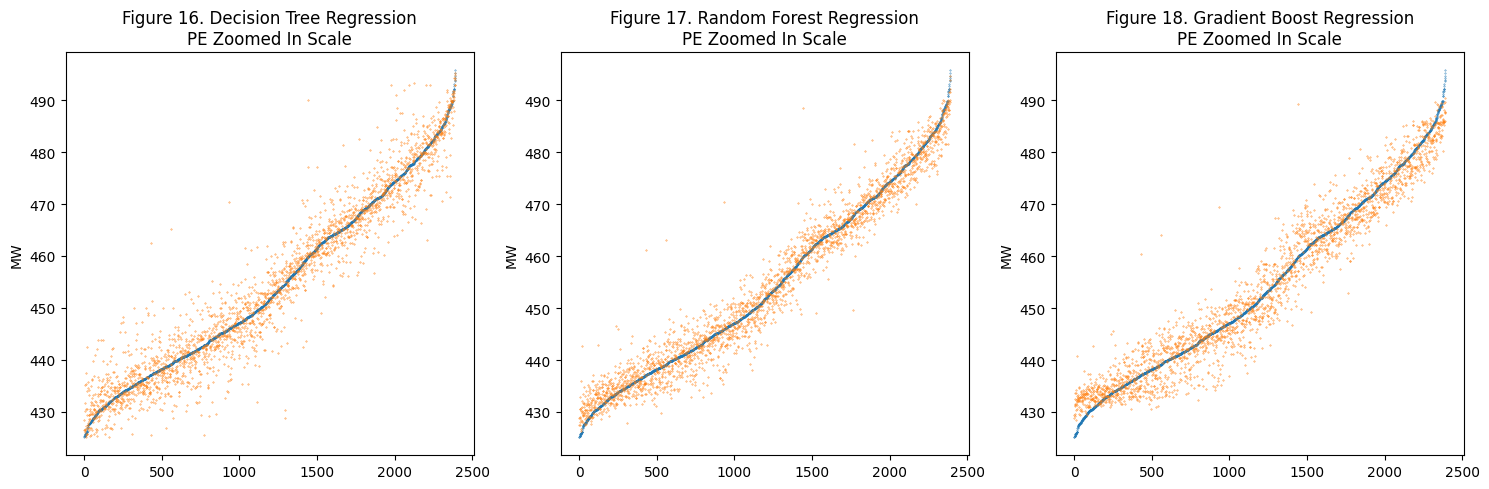

In [18]:
print(f"Table 5\n{model_df}")

fig = plt.figure(figsize=(15,5))

rfig = fig.add_subplot(131)
plt.title('Figure 16. Decision Tree Regression\nPE Zoomed In Scale')
plt.ylabel('MW')
mfig = fig.add_subplot(132)
plt.title('Figure 17. Random Forest Regression\nPE Zoomed In Scale')
plt.ylabel('MW')
lfig = fig.add_subplot(133)
plt.title('Figure 18. Gradient Boost Regression\nPE Zoomed In Scale')
plt.ylabel('MW')

rfig.scatter(dtregressor_y_df.index, dtregressor_y_df['y_test'], s=.1)

rfig.scatter(dtregressor_y_df.index, dtregressor_y_df['y_pred'], s=.1)

mfig.scatter(rfregressor_y_df.index, rfregressor_y_df['y_test'], s=.1)

mfig.scatter(rfregressor_y_df.index, rfregressor_y_df['y_pred'], s=.1)

lfig.scatter(gbregressor_y_df.index, gbregressor_y_df['y_test'], s=.1)

lfig.scatter(gbregressor_y_df.index, gbregressor_y_df['y_pred'], s=.1)

plt.tight_layout()

plt.show()

<h3>2.5 Performance Analysis</h3>

The random forest model had the better performance of the three models. Per the MSE metric, used for continuous variables, it had the objectively better performance. Per the Accuracy metric, used for classification variables, it had the worst performance; however, all of the accuracy scores are relatively similar and relatively low. The regression models perform better than the classification models, due to the variables being continuous; thus, the regression scores are the better metric. A visual look corroborates the random forest model having the better performance based on MSE. Per the MSE metric, the random forest’s performance is approximately 100% and 50% better than the competing models.<br>

For the specific business purpose, a linear regression could have sufficed - there’s a linear relationship between temperature (AT) and expected electrical output (PE). Random forests seem to simulate linear regressions more closely than the other models. The MSE is calculated at the most discrete level of measurement: the deepest leafs of a decision tree or each data point in a linear regression. 


<h2>Section 3: Understanding the Methods</h2>

The models — decision tree, random forest, and gradient boosting — are ordered by level of complexity. Single decision trees are the most simple model, appropriate for simple classification or regression problems. An example in the power production and distribution industry might be the example used in the assignment. A simple decision tree was effective in predicting expected energy output given variables such as temperature, pressure, relative humidity, and exhaust vacuum.<br><br>
A random forest model is a collection of simple decision trees. The aggregated trees are averaged, giving the final model robustness to noise and outliers. More complex iterations of the problem encountered in the assignment would be appropriate. Rather than just four variables, several hundred variables with missing data might benefit from the use of random forest models.<br><br>
Gradient boosting is the most complex model. Rather than take the simple average of many decision trees, each tree is made shallow and lined up sequentially. Gradient boosting is appropriate for problems where the highest accuracy is required. In the context of the power industry, financial instruments derived from the instantaneous price of electricity would definitely benefit from high accuracy.<br><br>
![Alt text](table_6.png)<br><br>
The conceptual difference between random forests and gradient boosting is in the ordering of the individual decision trees. Random forests still use deep decision trees, and the result of each decision tree is averaged to produce a final prediction. Gradient boosting uses shallow decision trees, and each tree is sequentially lined to the other. The end result is a model that iterates over past errors, producing higher accuracy.<br><br>
![Alt text](figures_18_19.png)<br><br>
Random forests solve the problem of overfitting by averaging multiple decision trees together. Bootstrapping is used to create multiple robust datasets from the original dataset. Some percentage, typically within one standard deviation, of the population is used to create population samples. The sample has the same amount of data, it is just a smaller sample of the original population. This creates an aggregated forest with a final prediction that is robust to variance and outliers.<br><br>
Gradient boosting shares a similar advantage over simple decision trees in that it provides robustness to noise and outliers. This is achieved by using several shallow decision trees, rather than bootstrapping. Each shallow model - called weak learners - is placed sequentially after the other, allowing for each iteration to improve on the previous iteration.<br><br>




<h2>Section 4: Business Impact & Recommendation</h2>

<h3>A power plant generator can cost approximately $100k per day to operate, and so the conclusion of the following calculations is that minimizing the amount of time a generator is idle can lead to cost savings:</h3>

The thinking is that if we can develop a temperature coefficient of full power, then we can predict generator operations to the extent we could optimize the amount of time excess generators are online. Generators take several hours, if not days, to startup, so the coordination of operating generators is an important operational consideration. Minimizing the idle time of generators can lead to cost savings.<br><br>
A power plant might be rated for 1750 MW at full power. Full power would be accomplished with 7 250 MW generators, or some combination of differently rated generators. A power distribution grid will have multiple sources of power, e.g. solar, wind, nuclear, gas. The dataset was collected from a combined cycle power plant, so, a power plant that is effective for generating base load - load that is relatively stable, rather than intermittent, like solar and wind can be.<br><br>
![Alt text](figure_20.png)<br><br>
Not all generators will be operating at the same time, so the operational schedule of generators can be optimized to lead to cost savings. Thus, having an accurate temperature coefficient of full power might lead to less idle time on generators, and thus, cost savings.<br><br>
For the purpose of demonstration, the simplest model - a decision tree - is selected. There is only one variable, Temperature (AT). The goal of the demonstration is to prove that we can accurately predict full power needs with only AT, and that that prediction can potentially lead to cost savings.<br><br>

In [19]:
eia_consumer_price = 0.1348

print(f"Monthly consumer price of electricity, August 2024:\n{eia_consumer_price} cents/KWhr")

Monthly consumer price of electricity, August 2024:
0.1348 cents/KWhr


(EIA 5.6.A 2025)

In [20]:
eia_plant_omf_costs = np.array([23.08,41.32,15.07,22.95]).mean()

print(f"Annual plant operating, maintenance, and fuel costs, 2024:\n{eia_plant_omf_costs} dollars/MWhr")

Annual plant operating, maintenance, and fuel costs, 2024:
25.605 dollars/MWhr


(EIA 8.4 2025)

In [21]:
wrtv_daily = [
['Day', 'Date', 'Conditions', 'HI', 'LO', 'Precip'],
['Saturday', '11/15/2025', 'Partly Cloudy', '73', '59', '0'],
['Sunday', ' 11/16/2025', 'Fair / Mostly Sunny', '70', '36', '0'],
['Monday', ' 11/17/2025', 'Sunny', '57', '33', '0'],
['Tuesday', ' 11/18/2025', 'Scattered Showers', '53', '42', '40'],
['Wednesday', '11/19/2025', 'Partly Cloudy', '56', '40', '0'],
['Thursday', '11/20/2025', 'Partly Cloudy', '62', '47', '0'],
['Friday', '11/21/2025', 'Partly Cloudy', '70', '49', '0'],
['Saturday', '11/22/2025', 'Partly Cloudy', '65', '42', '20']
]

(WRTV 2025)

In [22]:
wrtv_daily_df = pd.DataFrame(wrtv_daily[1:], columns=wrtv_daily[0])

In [23]:
wrtv_daily_df['AVG'] = wrtv_daily_df[['HI','LO']].astype(float).mean(axis=1)
print(f"Table 7\n{wrtv_daily_df}")

Table 7
         Day         Date           Conditions  HI  LO Precip   AVG
0   Saturday   11/15/2025        Partly Cloudy  73  59      0  66.0
1     Sunday   11/16/2025  Fair / Mostly Sunny  70  36      0  53.0
2     Monday   11/17/2025                Sunny  57  33      0  45.0
3    Tuesday   11/18/2025    Scattered Showers  53  42     40  47.5
4  Wednesday   11/19/2025        Partly Cloudy  56  40      0  48.0
5   Thursday   11/20/2025        Partly Cloudy  62  47      0  54.5
6     Friday   11/21/2025        Partly Cloudy  70  49      0  59.5
7   Saturday   11/22/2025        Partly Cloudy  65  42     20  53.5


In [24]:
ppep_df_sorted_subset = ppep_df_sorted.dropna(axis=0).reset_index(drop = True)

ppep_df_sorted_subset = pd.get_dummies(ppep_df_sorted_subset, drop_first = True)

y_temp = ppep_df_sorted_subset["PE"]

X_temp = ppep_df_sorted_subset.copy()[["AT"]]

X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temp, 
                                                                        y_temp, 
                                                                        test_size=0.25, 
                                                                        random_state=0)

In [25]:
dtregressor_temp = DecisionTreeRegressor(random_state=42)

dtregressor_temp.fit(X_train_temp, y_train_temp)

dtregressor_temp_y_pred = dtregressor_temp.predict(X_test_temp)

dtregressor_temp_mse = metrics.mean_squared_error(y_test_temp, dtregressor_temp_y_pred)

print(f"Decision Tree Regressor Mean Squared Error: {dtregressor_temp_mse}")

Decision Tree Regressor Mean Squared Error: 39.01956315175015


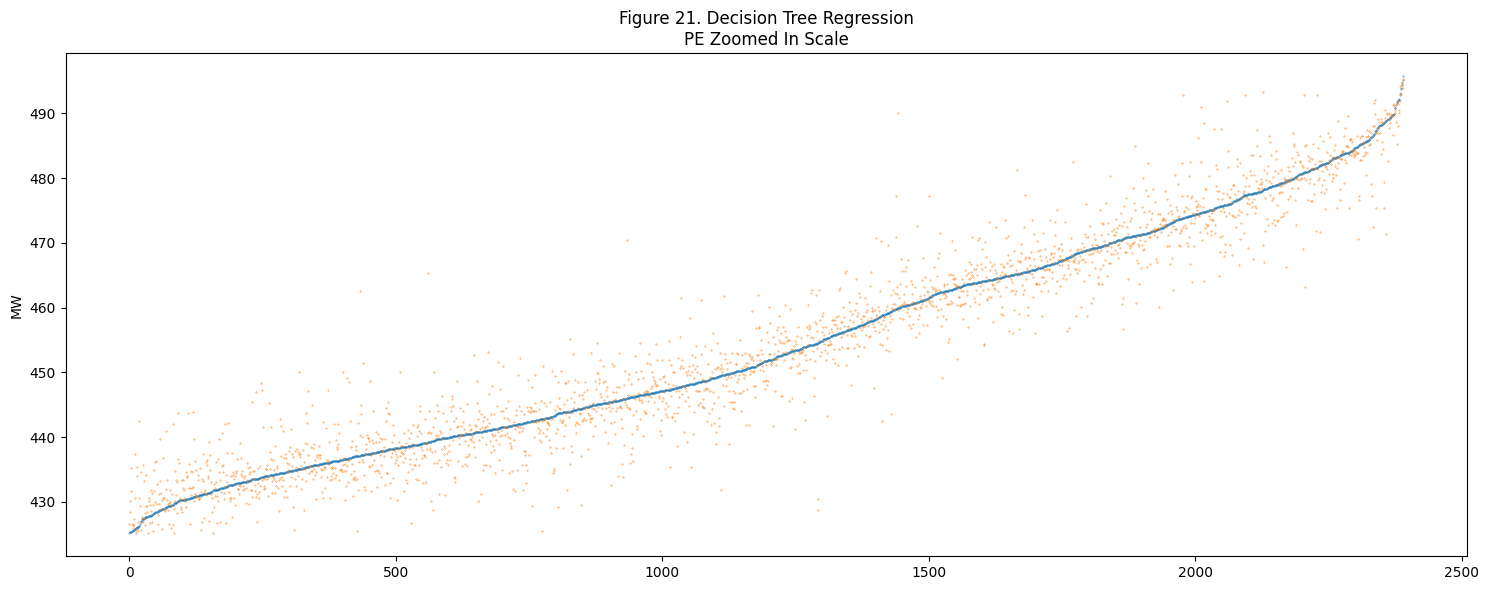

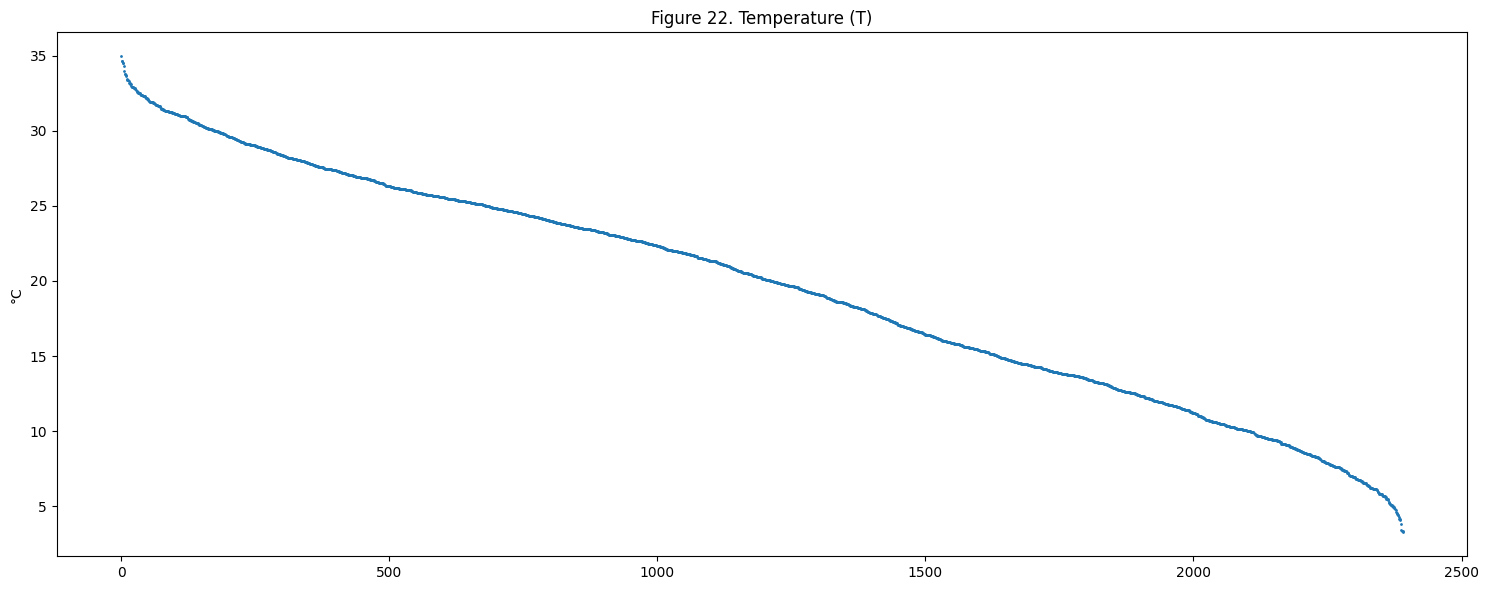

In [26]:
fig = plt.figure(figsize=(15,6))

plt.title('Figure 21. Decision Tree Regression\nPE Zoomed In Scale')

plt.ylabel('MW')

plt.scatter(dtregressor_y_df.index, dtregressor_y_df['y_test'], s=.1)

plt.scatter(dtregressor_y_df.index, dtregressor_y_df['y_pred'], s=.1)

plt.tight_layout()

plt.show()

fig = plt.figure(figsize=(15,6))

plt.title('Figure 22. Temperature (T)')

plt.ylabel('°C')

test_temp = X_test_temp.sort_values('AT').iloc[::-1].reset_index(drop=True)

plt.scatter(test_temp.index, test_temp, s=1)

plt.tight_layout()

plt.show()

The hypothesis above is the same as the relationship proven in the above analysis. Rather than use all variables - V, RH, P, AT - only AT is used. The above plots visually display an inversely proportional relationship, and that the predictions given by the decision tree are at least relatively close to the expected power output (PE).

In [27]:
predictions_wrtv = []

for temp_measurement in wrtv_daily_df['AVG']:
    temp_f = (float(temp_measurement) - 32) * 5/9
    
    tmp_df = pd.DataFrame([float(temp_f)], columns=['AT'])
    
    prediction = dtregressor_temp.predict(tmp_df)[0]
    
    predictions_wrtv.append([float(temp_f), prediction])

predictions_wrtv = pd.DataFrame(predictions_wrtv, columns=[['AT', 'PE']])

print(f"Table 8\n{predictions_wrtv}")

Table 8
          AT          PE
0  18.888889  453.700000
1  11.666667  473.484000
2   7.222222  476.150000
3   8.611111  476.333333
4   8.888889  483.820000
5  12.500000  472.450000
6  15.277778  462.717500
7  11.944444  471.790000


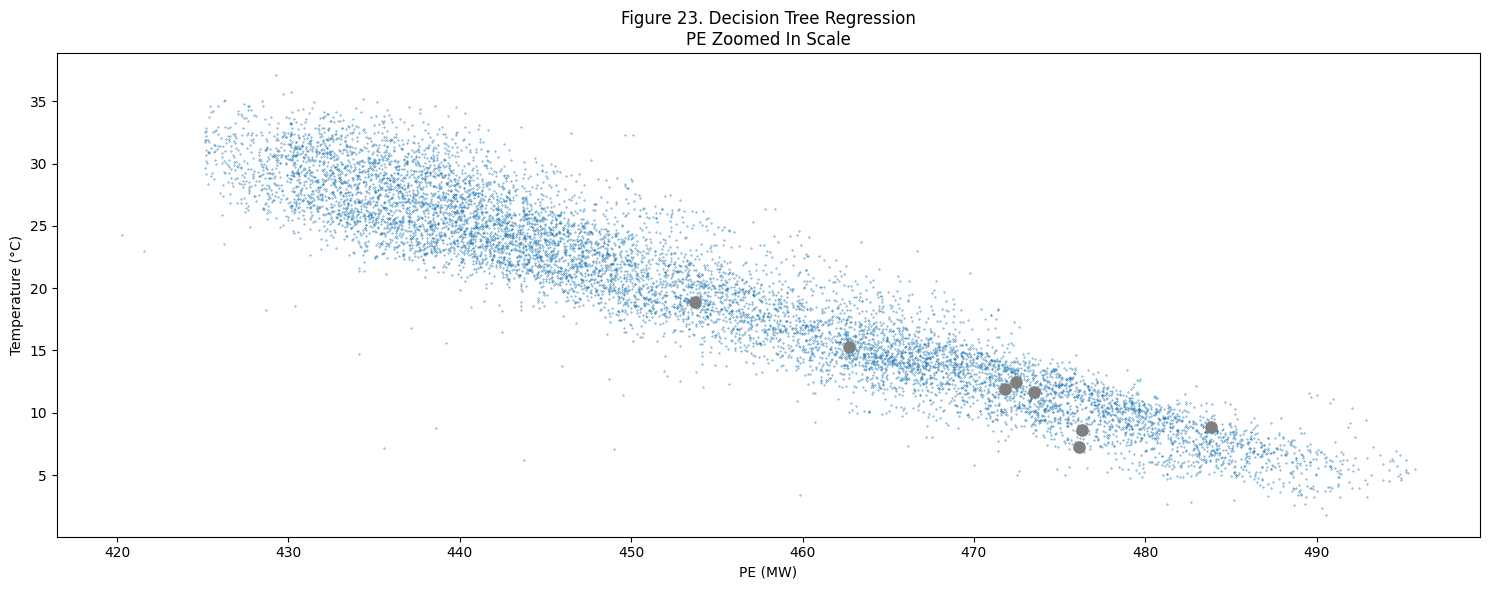

In [28]:
fig = plt.figure(figsize=(15,6))

plt.title('Figure 23. Decision Tree Regression\nPE Zoomed In Scale')

plt.ylabel('Temperature (°C)')

plt.xlabel('PE (MW)')

plt.scatter(ppep_df_sorted['PE'], ppep_df_sorted['AT'], s=.1)

plt.scatter(predictions_wrtv['PE'], predictions_wrtv['AT'], s=65, color='gray')

plt.tight_layout()

plt.show()

In [29]:
nws_t = [
['DY', 'MAX', 'MIN'],
['23', '87', '62'],
['24', '88', '67'], 
['25', '88', '72'], 
['26', '83', '70'], 
['27', '72', '67'], 
['28', '81', '65'], 
['29', '74', '63'], 
['30', '73', '67']]

(NWS 2025)

In [30]:
nws_t_df = pd.DataFrame(nws_t[1:], columns=nws_t[0])

nws_t_df['AVG'] = nws_t_df[['MAX','MIN']].astype(float).mean(axis=1)

print(f"Table 9\n{nws_t_df}")

Table 9
   DY MAX MIN   AVG
0  23  87  62  74.5
1  24  88  67  77.5
2  25  88  72  80.0
3  26  83  70  76.5
4  27  72  67  69.5
5  28  81  65  73.0
6  29  74  63  68.5
7  30  73  67  70.0


In [31]:
predictions_nws = []

for temp_measurement in nws_t_df['AVG']:
    temp_f = (float(temp_measurement) - 32) * 5/9
    
    tmp_df = pd.DataFrame([float(temp_f)], columns=['AT'])
    
    prediction = dtregressor_temp.predict(tmp_df)[0]
    
    predictions_nws.append([float(temp_f), prediction])

predictions_nws = pd.DataFrame(predictions_nws, columns=[['AT', 'PE']])

print(f"Table 10\n{predictions_nws}")

Table 10
          AT          PE
0  23.611111  444.025000
1  25.277778  439.432500
2  26.666667  440.210000
3  24.722222  443.060000
4  20.833333  448.890000
5  22.777778  440.593333
6  20.277778  452.660000
7  21.111111  451.861667


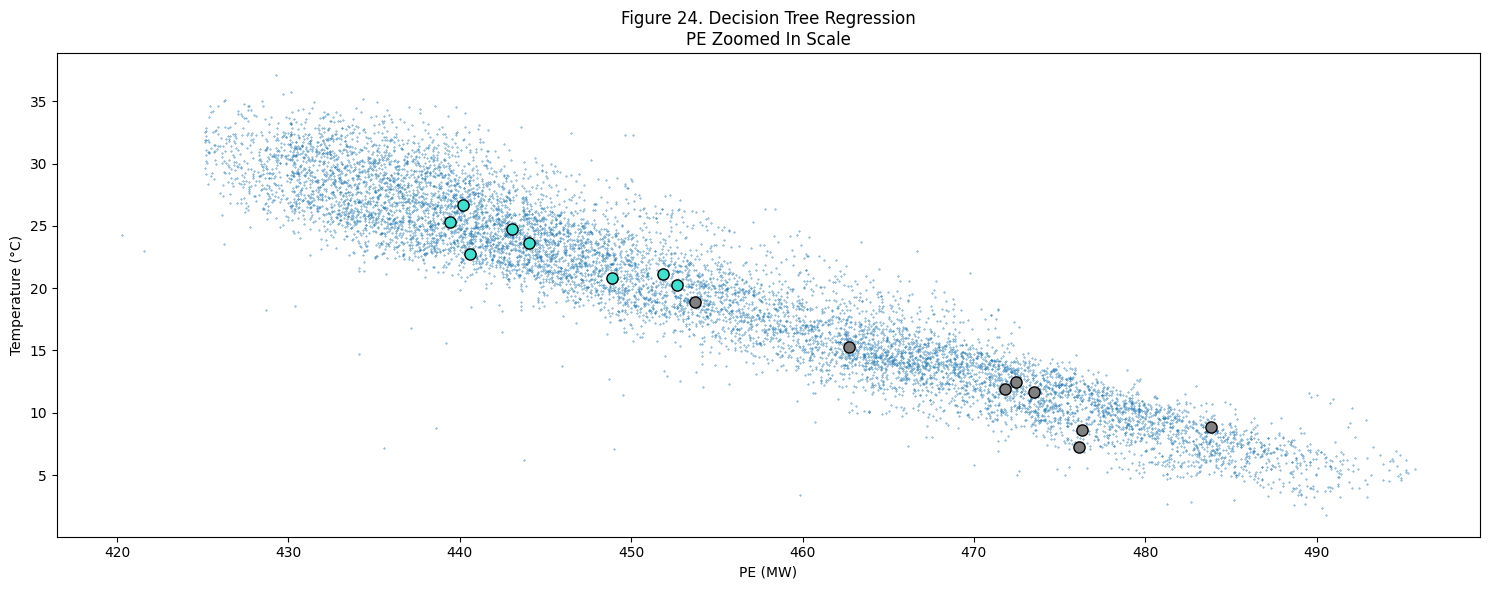

In [32]:
fig = plt.figure(figsize=(15,6))

plt.title('Figure 24. Decision Tree Regression\nPE Zoomed In Scale')

plt.ylabel('Temperature (°C)')

plt.xlabel('PE (MW)')

plt.scatter(ppep_df_sorted['PE'], ppep_df_sorted['AT'], s=.1)

plt.scatter(predictions_wrtv['PE'], predictions_wrtv['AT'], s=65, color='gray', edgecolor='black')

plt.scatter(predictions_nws['PE'], predictions_nws['AT'], s=65, color='#40e0d0', edgecolor='black')

plt.tight_layout()

plt.show()

After running the predictive models on National Weather Service data and local WRTV data, we obtain a plot of Temperature (AT) vs. Expected Power Output (PE). Our predictions seem to fall inline with the Combined Cycle Power Plant dataset measurements. The mean-squared error is relatively high at approximately 39; however, given the relative accuracy of a visual inspection, and the fact that only AT is being used for the purposes of demonstration, it is not unacceptably high. With measurements of relative humidity, which has a high feature importance as the complexity of the model is raised, our predictions could tighten up accuracy (see section 5.1).<br><br>

The thinking is that if the power plant is at a threshold of having to bring on an additional generator, then, having an accurate prediction of full power per a given temperature might save a couple of hours or days of idle time on a generator.

In [33]:
plant_cost = []

for name, row in predictions_nws.iterrows():
    pe = row.PE
    
    temp = row.AT

    ep_plant_cost = pe * eia_plant_omf_costs # MW * dollars/MWHR

    ep_consumer_price = pe * 1000 * eia_consumer_price # MW * 1000 KW/MW * cents/KWhr

    daily_price = ep_plant_cost * 24
        
    plant_cost.append([row.PE, row.AT, daily_price])

for name, row in predictions_wrtv.iterrows():
    pe = row.PE
    
    temp = row.AT

    ep_plant_cost = pe * eia_plant_omf_costs # MW * dollars/MWHR

    ep_consumer_price = pe * 1000 * eia_consumer_price # MW * 1000 KW/MW * cents/KWhr

    daily_price = ep_plant_cost * 24
        
    plant_cost.append([row.PE, row.AT, daily_price])

In [34]:
plant_cost = pd.DataFrame(plant_cost, columns=[['PE','AT','Daily Price']])

In [35]:
average_daily_cost = plant_cost['Daily Price'].mean()
average_daily_cost

Daily Price    281572.19343
dtype: float64

In [36]:
average_daily_cost/3

Daily Price    93857.39781
dtype: float64

Per our predictions, the average daily operating, maintenance, and fuel costs of a typical power plant are approximately \\$300k per day. The Combined Cycle Power Plant operates at full load of approximately 440 MW to 480 MW. Two 300 MW generators could supply full load, with a total of three generators to provide spinning reserve capacity. Given the size of generators, it could be possible that the spinning reserve capacity could be optimized to produce cost savings. If each generator costs about \\$100k per day to operate, then at times that the power plant as not at full load, being able to not operate one generator could be significant. 

<h2>Section 5: Feature Importance Analysis</h2>

<h3>5.1 Feature Importance Comparison</h3>

Accuracy = 0.0732


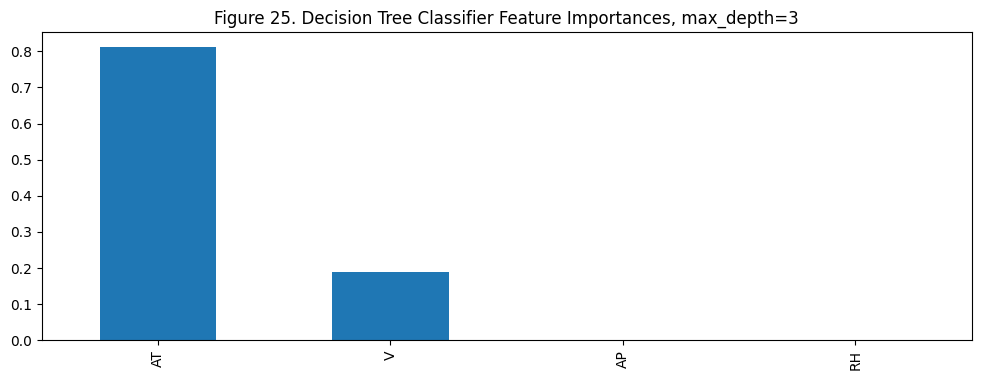

Accuracy = 0.1221


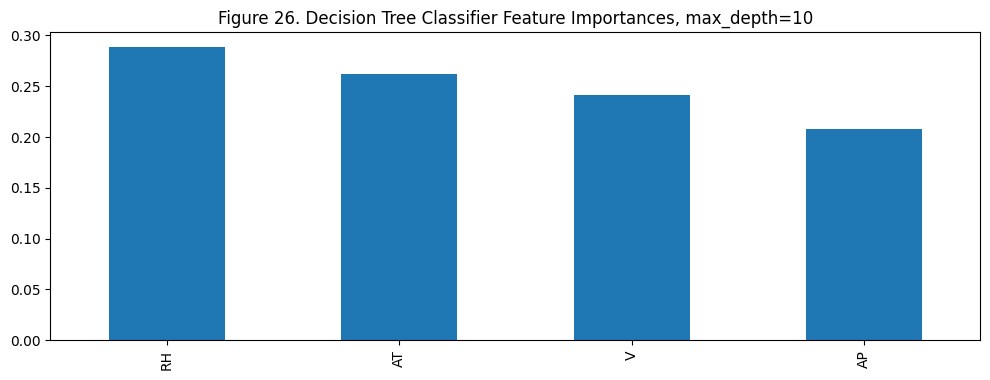

In [37]:
dtclassifier = DecisionTreeClassifier(max_depth=3, random_state=42)
dtclassifier.fit(X_train_classifier, y_train_classifier)
dtclassifier_y_pred = dtclassifier.predict(X_test_classifier)


dtclassifier_accuracy = metrics.accuracy_score(y_test_classifier, dtclassifier_y_pred)
print(f"Accuracy = {np.round(dtclassifier_accuracy,4)}")

importances = dtclassifier.feature_importances_
forest_importances = pd.Series(importances, index=X_train_classifier.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 25. Decision Tree Classifier Feature Importances, max_depth=3")
plt.show()

dtclassifier = DecisionTreeClassifier(max_depth=10, random_state=42)
dtclassifier.fit(X_train_classifier, y_train_classifier)
dtclassifier_y_pred = dtclassifier.predict(X_test_classifier)

dtclassifier_accuracy = metrics.accuracy_score(y_test_classifier, dtclassifier_y_pred)
print(f"Accuracy = {np.round(dtclassifier_accuracy,4)}")

importances = dtclassifier.feature_importances_
forest_importances = pd.Series(importances, index=X_train_classifier.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 26. Decision Tree Classifier Feature Importances, max_depth=10")
plt.show()

MSE = 26.7537


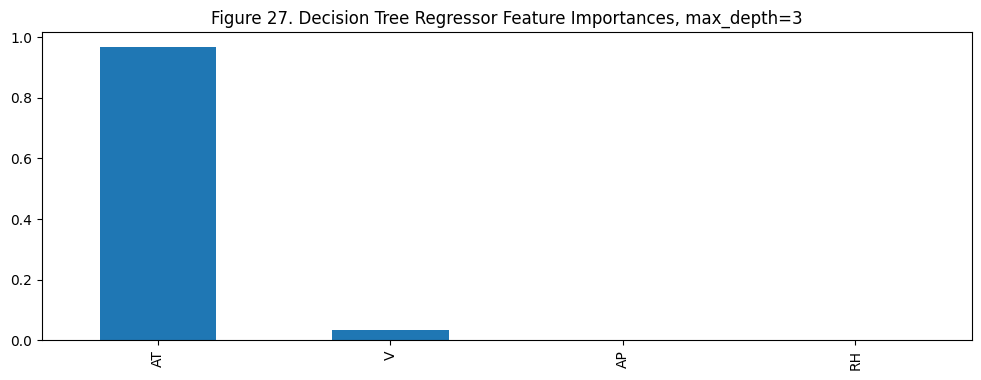

MSE = 16.2075


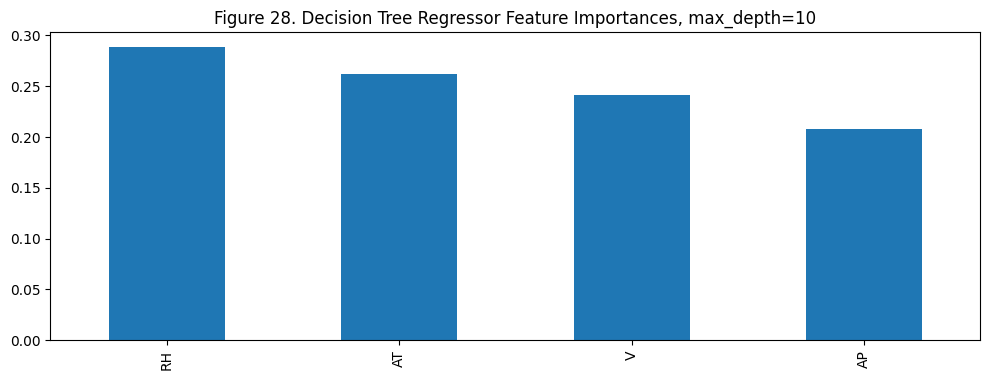

In [38]:
dtregressor = DecisionTreeRegressor(max_depth=3, random_state=42)
dtregressor.fit(X_train, y_train)
dtregressor_y_pred = dtregressor.predict(X_test)

dtregressor_mse = metrics.mean_squared_error(y_test, dtregressor_y_pred)
print(f"MSE = {np.round(dtregressor_mse,4)}")

importances = dtregressor.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 27. Decision Tree Regressor Feature Importances, max_depth=3")
plt.show()

dtregressor = DecisionTreeRegressor(max_depth=10, random_state=42)
dtregressor.fit(X_train, y_train)
dtregressor_y_pred = dtregressor.predict(X_test)

dtregressor_mse = metrics.mean_squared_error(y_test, dtregressor_y_pred)
print(f"MSE = {np.round(dtregressor_mse,4)}")

importances = dtclassifier.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 28. Decision Tree Regressor Feature Importances, max_depth=10")
plt.show()

Accuracy = 0.0723


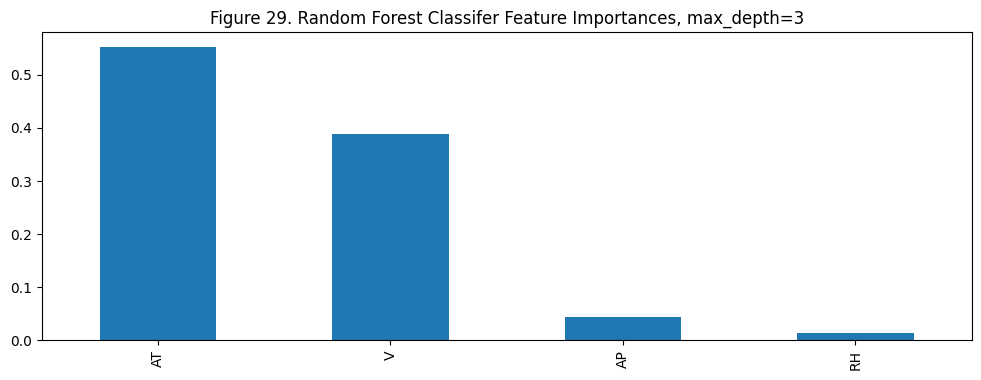

Accuracy = 0.1375


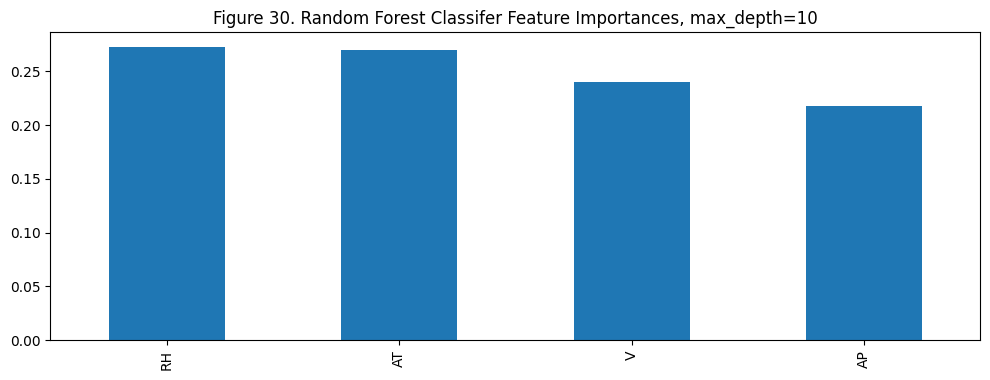

In [39]:
rfclassifier = RandomForestClassifier(max_depth=3, random_state=42)
rfclassifier.fit(X_train_classifier, y_train_classifier)
rfclassifier_y_pred = rfclassifier.predict(X_test_classifier)

rfclassifier_accuracy = metrics.accuracy_score(y_test_classifier, rfclassifier_y_pred)
print(f"Accuracy = {np.round(rfclassifier_accuracy,4)}")
importances = rfclassifier.feature_importances_
forest_importances = pd.Series(importances, index=X_train_classifier.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 29. Random Forest Classifer Feature Importances, max_depth=3")
plt.show()

rfclassifier = RandomForestClassifier(max_depth=10, random_state=42)
rfclassifier.fit(X_train_classifier, y_train_classifier)
rfclassifier_y_pred = rfclassifier.predict(X_test_classifier)

rfclassifier_accuracy = metrics.accuracy_score(y_test_classifier, rfclassifier_y_pred)
print(f"Accuracy = {np.round(rfclassifier_accuracy,4)}")
importances = rfclassifier.feature_importances_
forest_importances = pd.Series(importances, index=X_train_classifier.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 30. Random Forest Classifer Feature Importances, max_depth=10")
plt.show()

MSE = 23.9693


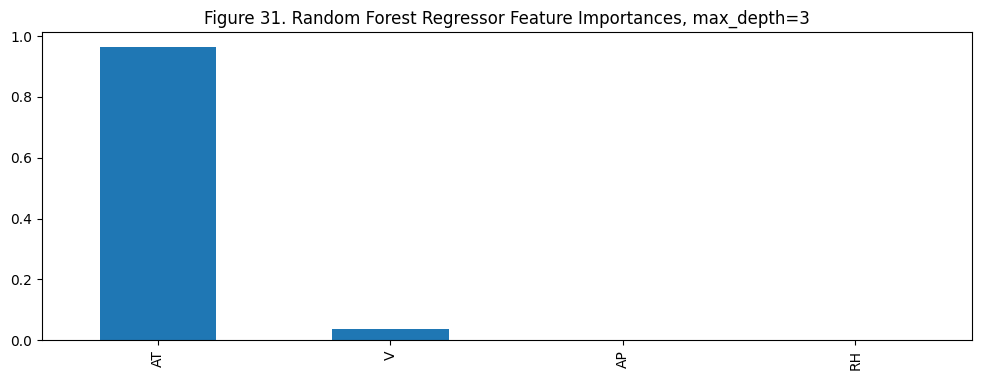

MSE = 12.5476


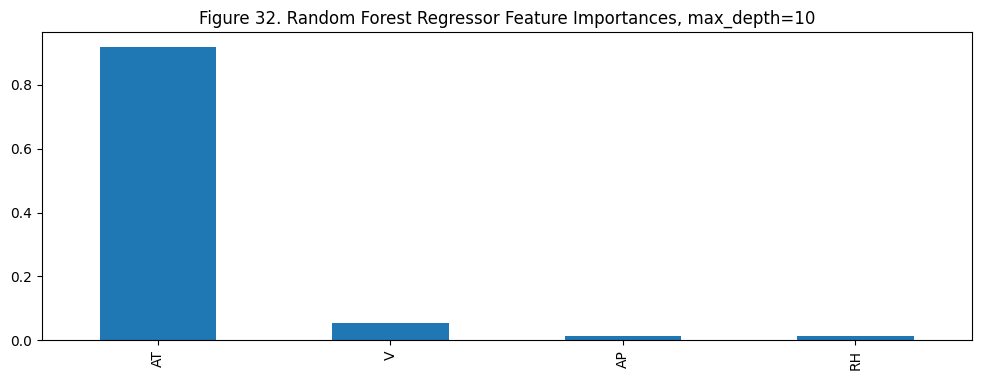

In [40]:
rfregressor = RandomForestRegressor(max_depth=3, random_state=42)
rfregressor.fit(X_train, y_train)
rfregressor_y_pred = rfregressor.predict(X_test)

rfregressor_mse = metrics.mean_squared_error(y_test, rfregressor_y_pred)
print(f"MSE = {np.round(rfregressor_mse,4)}")
importances = rfregressor.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 31. Random Forest Regressor Feature Importances, max_depth=3")
plt.show()

rfregressor = RandomForestRegressor(max_depth=10, random_state=42)
rfregressor.fit(X_train, y_train)
rfregressor_y_pred = rfregressor.predict(X_test)

rfregressor_mse = metrics.mean_squared_error(y_test, rfregressor_y_pred)
print(f"MSE = {np.round(rfregressor_mse,4)}")
importances = rfregressor.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 32. Random Forest Regressor Feature Importances, max_depth=10")
plt.show()

Accuracy = 0.1171


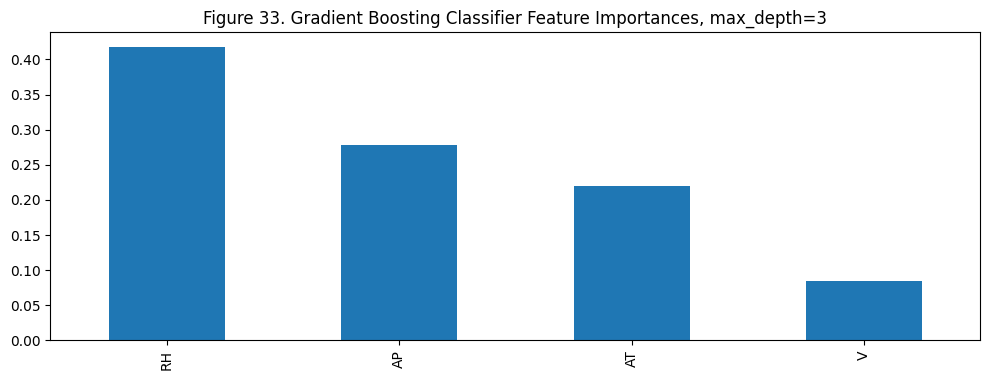

Accuracy = 0.1384


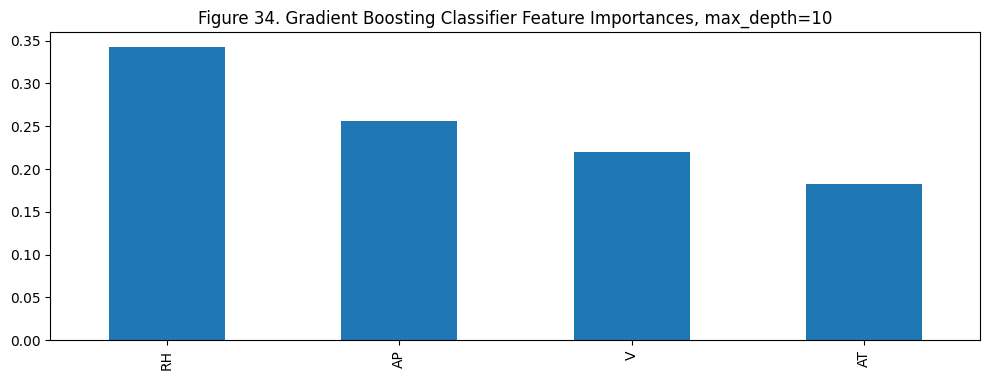

In [41]:
gbclassifier = GradientBoostingClassifier(max_depth=3, random_state=42)
gbclassifier.fit(X_train_classifier, y_train_classifier)
gbclassifier_y_pred = gbclassifier.predict(X_test_classifier)

gbclassifier_accuracy = metrics.accuracy_score(y_test_classifier, gbclassifier_y_pred)
print(f"Accuracy = {np.round(gbclassifier_accuracy,4)}")
importances = gbclassifier.feature_importances_
forest_importances = pd.Series(importances, index=X_train_classifier.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 33. Gradient Boosting Classifier Feature Importances, max_depth=3")
plt.show()

gbclassifier = GradientBoostingClassifier(max_depth=10, random_state=42)
gbclassifier.fit(X_train_classifier, y_train_classifier)
gbclassifier_y_pred = gbclassifier.predict(X_test_classifier)

gbclassifier_accuracy = metrics.accuracy_score(y_test_classifier, gbclassifier_y_pred)
print(f"Accuracy = {np.round(gbclassifier_accuracy,4)}")
importances = gbclassifier.feature_importances_
forest_importances = pd.Series(importances, index=X_train_classifier.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 34. Gradient Boosting Classifier Feature Importances, max_depth=10")
plt.show()

MSE = 15.0765


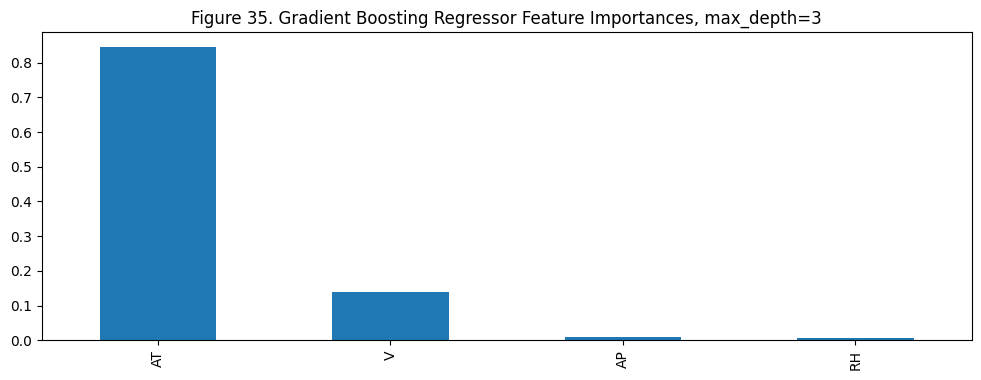



MAX_DEPTH = 10
Feature Importances
MSE = 10.1016


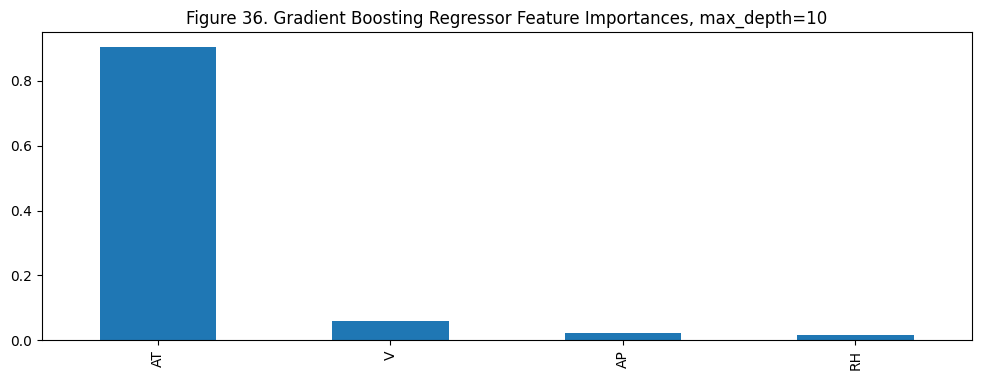

In [42]:
gbregressor = GradientBoostingRegressor(max_depth=3, random_state=42)
gbregressor.fit(X_train, y_train)
gbregressor_y_pred = gbregressor.predict(X_test)

gbregressor_mse = metrics.mean_squared_error(y_test, gbregressor_y_pred)
print(f"MSE = {np.round(gbregressor_mse,4)}")
importances = gbregressor.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 35. Gradient Boosting Regressor Feature Importances, max_depth=3")
plt.show()

gbregressor = GradientBoostingRegressor(max_depth=10, random_state=42)
gbregressor.fit(X_train, y_train)
gbregressor_y_pred = gbregressor.predict(X_test)

print(f"\n\nMAX_DEPTH = 10")
print(f"Feature Importances")
gbregressor_mse = metrics.mean_squared_error(y_test, gbregressor_y_pred)
print(f"MSE = {np.round(gbregressor_mse,4)}")
importances = gbregressor.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
fig = plt.subplots(figsize=(12,4))
forest_importances.plot.bar()
plt.title(f"Figure 36. Gradient Boosting Regressor Feature Importances, max_depth=10")
plt.show()

<h3>5.2 Feature Importance Comparison</h3>

Curiously, for many of the models, Temperature (AT) is the most important feature at max_depth=3, and that matches with the visual inspection. At max_depth=10, Relative Humidity (RH) becomes the most important feature. Based on the physical characteristics of a power plant, this should make sense. RT affects the evaporative cooling available to a plant heat engine, and so, it makes sense it would be an important feature.<br><br>
The conventional knowledge is that a high variance in an independent feature might result in overfitting. There isn't evidence of overfitting in this prediction set. The variance of Temperature vs. Relative Humidity seems to match the difference between feature importance for the max_depth=3 model and the max_depth=10 model. Given how important Relative Humidity is to evaporative cooling, it makes sense given knowledge of a power plant that it would be one of the most, if not the most, important feature(s). This leads to the belief that the models with higher depths have a higher sensitivity to minute changes in Relative Humidity.<br><br>
The temperature measurements may be dry bulb temperature measurements rather than wet bulb temperature measurements. This would lead to a difference in accuracy if the minute changes of Relative Humidity are given additional weight. Wet bulb temperature would take into account RH, and so a wet bulb temperature measurement might remain the most important feature even as model complexity is raised.


<h2>Reflection</h2>

For the given dataset, the accuracy of all of the models were comparable. I used a simple decision tree to perform the temperature coefficient analysis, and the results were acceptable to demonstrate monetary savings. Additional accuracy could be obtained with a similar study using a more complex model. Relative humidity (RH) data would have to be obtained. For the purposes of demonstrating to stakeholders some overarching concepts, the simple decision tree is effective due to the minimal amount of time required to compile the data and develop a report. As more complexity is required, more advanced models can be used to squeeze additional accuracy from a given dataset. This is inline with what we have learned in class. 

As discussed in Section 5.2, the more complex models take into account variables with a higher level of variance. Temperature (AT) shows a visually linear relationship. The relationship is inversely proportional, and for the purposes of demonstrating the temperature coefficient, effective. RH has a much more complex relationship to Expected Power Output (PE), and so, the more complex models are able to predict PE with a higher level of accuracy.

This assignment was useful in demonstrating that simpler models can be useful in creating demonstrations, especially for stakeholders on the business side rather than on the operational or engineering side. There is a difference between talking to business stakeholders about cost savings vs. building a complex, operational model to put those cost saving models into place. I could have spent an even longer amount of time on the assignment squeezing as much accuracy as I could find with more complex models; however, as a rapid prototype of a more complex model, a simple decision tree sufficed.

<h2>References</h2>

National Weather Service. (2025, November 16). Preliminary climatology data (CF6). U.S. Department of Commerce, National Oceanic and Atmospheric Administration. https://forecast.weather.gov/product.php?site=CRH&issuedby=RIC&product=CF6&format=CI&version=3&glossary=1

U.S. Energy Information Administration. (2025, October 24). Electric Power Monthly (Table 8.4. Average Power Plant Operating Expenses for Major U.S. Investor-Owned Electric Utilities, 2014 through 2024 (Mills per Kilowatthour). https://www.eia.gov/electricity/annual/html/epa_08_04.html

U.S. Energy Information Administration. (2025, October 24). Electric Power Monthly (Table 5.6.A. Average Retail Price of Electricity, Residential, Commercial, Industrial, Transportation, and All Sectors, 2024 and 2025). https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=epmt_5_6_a.

WTVR.com. (2025, November 16). Daily forecast. https://www.wtvr.com/weather/daily-forecast



<h2>Relevant Calculations and Figures</h2>

In [43]:

consumer_price = []

for name, row in predictions_nws.iterrows():
    pe = row.PE
    
    temp = row.AT

    ep_consumer_price = pe * 1000 * eia_consumer_price # MW * 1000 KW/MW * cents/KWhr
        
    daily_price = ep_consumer_price * 24

    consumer_price.append([row.PE, row.AT, daily_price])

for name, row in predictions_wrtv.iterrows():
    pe = row.PE
    
    temp = row.AT

    ep_consumer_price = pe * 1000 * eia_consumer_price # MW * 1000 KW/MW * cents/KWhr

    daily_price = ep_consumer_price * 24

    consumer_price.append([row.PE, row.AT, daily_price])

consumer_price = np.array(consumer_price)

consumer_price = pd.DataFrame(consumer_price, columns=[['PE','AT','$']]).astype(float)

estimated_profit = []

for name, row in predictions_nws.iterrows():
    pe = row.PE
    
    temp = row.AT

    ep_plant_cost = pe * eia_plant_omf_costs # MW * dollars/MWHR

    ep_consumer_price = pe * 1000 * eia_consumer_price # MW * 1000 KW/MW * cents/KWhr

    daily_price = (ep_consumer_price - ep_plant_cost) * 24
        
    estimated_profit.append([row.PE, row.AT, daily_price])

for name, row in predictions_wrtv.iterrows():
    pe = row.PE
    
    temp = row.AT

    ep_plant_cost = pe * eia_plant_omf_costs # MW * dollars/MWHR

    ep_consumer_price = pe * 1000 * eia_consumer_price # MW * 1000 KW/MW * cents/KWhr

    daily_price = (ep_consumer_price - ep_plant_cost) * 24
        
    estimated_profit.append([row.PE, row.AT, daily_price])

estimated_profit = np.array(estimated_profit)

estimated_profit = pd.DataFrame(estimated_profit, columns=[['PE','AT','$']]).astype(float)



In [44]:
estimated_profit['$'].mean()

$    1.200792e+06
dtype: float64

What the above visualization show is that on average, a power plant sees a daily revenue of approximately $1.2 million. The variation in color of the Estimated Profit variable is affected by AT. The difference between the highest and lowest measurements should give us a mostly accurate estimate of cost savings.

In [45]:
estimated_profit['$'].max() - estimated_profit['$'].min()

$    116325.4335
dtype: float64

For the temperature variations seen in the Combined Cycle Power Plant, we can estimate a difference of $116k across the whole range.

In [46]:
temp_diff = estimated_profit['AT'].diff(1).mean()

pe_diff = estimated_profit['PE'].diff(1).mean()

temperature_coefficient_of_full_power_output = 1/np.round(pe_diff.values[0]/temp_diff.values[0],1)

print(temperature_coefficient_of_full_power_output)

-0.4166666666666667


In [47]:
temp_diff = -(estimated_profit['AT'].max() - estimated_profit['AT'].min())
pe_diff = estimated_profit['PE'].max() - estimated_profit['PE'].min()
pe_diff.values[0]/temp_diff.values[0]

-2.2827857142857133

We are able to calculate a temperature coefficient of full power output. The calculated value is approximately -2.3 MW/°C (given the inversely proportional relationship, the temperature difference is made negative). From the start point of approximately 35 °C, every -0.42 drop in temperature raises the expected power output of the plant by 1 MW.

We can translate this into a savings calculation per °C.

In [48]:
temp_diff = estimated_profit['AT'].diff(1).mean()

price_diff = estimated_profit['$'].diff(1).mean()

profit_per_degree = np.round(price_diff.values[0]/temp_diff.values[0],1)

print(profit_per_degree)

-6236.8


One °C translates to approximately $6236.8